# Objective

HDB is interested to monitor price trends for Executive Condominiums (ECs), a type of residential property developed and sold by private developers (i.e. 
with facilities similar to condominiums) yet subsidised to some degree by the government (first-time buyers are eligible for CPF housing grants, similar to 
HDB flats, if they buy a new EC during its launch).
HDB is particularly interested to predict the price of new EC flats at two specific points in time:

• 5 years after lease commencement, when an EC reaches its Minimum Occupancy Period (MOP), resulting in a significant number of flats flooding 
the resale market; and

• 10 years after lease commencement, when an EC becomes privatised and generally indistinguishable from comparable private condominiums.




### Import Libraries

In [1]:
import math 
import glob
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

### Helper functions

In [2]:
# plot histogram and boxplot for all continous features to check the distribution
def plot_continuous_feature_distributions(df_, float_columns):
    import numpy as np
    import math
    import matplotlib.pyplot as plt

    n = len(float_columns)
    ncols = 2  # one col for histogram, one for boxplot
    nrows = n  # one row per feature

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 5))

    # Ensure axes is always 2D even if only one feature
    if n == 1:
        axes = np.array([axes])

    for i, feature in enumerate(float_columns):
        col = df_[feature].dropna()
        value_counts = len(col)

        # --- Histogram ---
        axes[i, 0].hist(col, bins=int(np.round(math.sqrt(value_counts))))
        axes[i, 0].set_title(f'Histogram — {feature}')
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel('Frequency')

        # --- Boxplot ---
        axes[i, 1].boxplot(col)
        axes[i, 1].set_title(f'Boxplot — {feature}')

        # --- Stats as figure row title ---
        mean, median     = col.mean(), col.median()
        min_val, max_val = col.min(), col.max()
        skew, kurt       = col.skew(), col.kurt()
        iqr              = col.quantile(0.75) - col.quantile(0.25)

        stats_text = (
            f'Mean: {mean:.2f}  |  Median: {median:.2f}  |  '
            f'Min: {min_val:.2f}  |  Max: {max_val:.2f}  |  '
            f'Skew: {skew:.2f}  |  Kurt: {kurt:.2f}  |  IQR: {iqr:.2f}'
        )
        # Place stats text between the two plots as a row label
        axes[i, 0].annotate(
            stats_text,
            xy=(1.0, -0.15),
            xycoords='axes fraction',
            ha='center', fontsize=9, color='gray'
        )

    plt.suptitle('Continuous Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()



def plot_categorical_feature_countplots(df_, cat_columns):
    n = len(cat_columns)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
    axes = axes.flatten()  # makes indexing easier

    for i, cat_column in enumerate(cat_columns):
        sns.countplot(x=cat_column, data=df_, ax=axes[i])
        axes[i].set_title(f'Count Plot for {cat_column}')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print value counts separately after the plot
    for cat_column in cat_columns:
        print(f'Value counts for {cat_column}:')
        print(df_[cat_column].value_counts())
        print(f'Total count: {df_[cat_column].value_counts().sum()}')
        print("\n")

# str_columns.remove('street')
# str_columns.remove('project')
# str_columns.remove('tenure')
# str_columns.append('zones')

def plot_discrete_feature_distributions(df_, discrete_columns):
    import math
    import matplotlib.pyplot as plt
    import seaborn as sns

    n = len(discrete_columns)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 5))
    axes = axes.flatten()

    for i, col in enumerate(discrete_columns):
        series = df_[col].dropna()
        
        # Use countplot if low cardinality, bar of value_counts if high
        unique_vals = series.nunique()
        if unique_vals <= 30:
            sns.countplot(x=col, data=df_, ax=axes[i], order=sorted(series.unique()))
        else:
            # Too many unique values — plot top 20 by frequency
            top = series.value_counts().nlargest(20)
            axes[i].bar(top.index.astype(str), top.values)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')

        # Stats annotation
        mean, median = series.mean(), series.median()
        mode         = series.mode()[0]
        min_val      = series.min()
        max_val      = series.max()

        stats_text = (
            f'Mean: {mean:.2f}  |  Median: {median}  |  Mode: {mode}  |  '
            f'Min: {min_val}  |  Max: {max_val}  |  Unique: {unique_vals}'
        )
        axes[i].set_title(f'{col}\n{stats_text}', fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused slots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Discrete Feature Distributions', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print value counts
    for col in discrete_columns:
        print(f'Value counts for {col}:')
        print(df_[col].value_counts().sort_index())
        print(f'Total count: {df_[col].value_counts().sum()}')
        print("\n")


import numpy as np
import datetime

def get_remaining_lease(tenure):
    """
    Returns remaining lease:
    - 999 for any variant of Freehold
    - 99 for typical leasehold (99 yrs lease*, *99-year lease*, etc)
    - For 999-year leaseholds, returns 999
    - For other digit-year patterns, returns the digit
    - np.nan if cannot deduce
    """
    if pd.isnull(tenure):
        return np.nan

    tenure_s = str(tenure).lower()

    # Freehold
    if "freehold" in tenure_s:
        return 999

    # 999-year lease
    if re.search(r'999[\s\-]*year', tenure_s) or re.search(r'999[\s\-]*yrs', tenure_s):
        return 999

    # 99-year lease
    if re.search(r'99[\s\-]*year', tenure_s) or re.search(r'99[\s\-]*yrs', tenure_s):
        return 99

    # Any other NNN-year lease
    match = re.search(r'(\d{2,4})[\s\-]*(year|yrs)', tenure_s)
    if match:
        return int(match.group(1))

    return np.nan

from datetime import datetime
current_year = datetime.today().year

def smart_remaining_lease(tenure):
    """
    Determines remaining lease from tenure string.
    
    - If 'Freehold': 999
    - If '99 yrs lease commencing from YYYY', calculates: 99 - (current_year - YYYY)
    - If '999 yrs lease ... from YYYY', just 999
    - If ambiguous, falls back to previous get_remaining_lease()
    """
    if pd.isnull(tenure):
        return np.nan

    t = str(tenure).lower().strip()

    if "freehold" in t:
        return 999
    
    # 999-year lease, regardless of commencement year
    if re.search(r'999[\s\-]*year', t) or re.search(r'999[\s\-]*yrs', t):
        return 999

    # 99 yrs lease commencing from YYYY or similar patterns
    match_99 = re.search(r'99[\s\-]*yrs* lease.*?from (\d{4})', t)
    if match_99:
        lease_start = int(match_99.group(1))
        years_passed = current_year - lease_start
        remaining = 99 - years_passed
        if remaining < 0:
            return 0  # Lease expired
        return remaining
    
    # Other NNN-year lease commencing from YYYY
    match_nnn = re.search(r'(\d{2,4})[\s\-]*yrs* lease.*?from (\d{4})', t)
    if match_nnn:
        nnn = int(match_nnn.group(1))
        lease_start = int(match_nnn.group(2))
        years_passed = current_year - lease_start
        remaining = nnn - years_passed
        if remaining < 0:
            return 0
        return remaining

    # Fallback: use old get_remaining_lease logic
    return get_remaining_lease(tenure)

### Load Data
- Combine all the json into one dataframe

In [3]:
# Load data
DATA_DIR = Path.cwd() / "data"
if Path.cwd().name == "notebook":
    DATA_DIR = Path.cwd().parent / "data"

json_paths = sorted(glob.glob(str(DATA_DIR / "*.json")))

dfs = []
for p in json_paths:
    with open(p, encoding="utf-8") as f:
        payload = json.load(f)
    dfs.append(pd.DataFrame(payload["Result"]))

df_raw = pd.concat(dfs, ignore_index=True)

In [4]:
df_raw.head()

,street,x,project,y,transaction,marketSegment
0,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,"[{'area': '257', 'floorRange': '-', 'noOfUnits...",RCR
1,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,"[{'area': '308', 'floorRange': '-', 'noOfUnits...",RCR
2,BEACH ROAD,NaN,AUREA,NaN,"[{'area': '66', 'floorRange': '21-25', 'noOfUn...",CCR
3,COVE DRIVE,28382.47067,TURQUOISE,25008.33592,"[{'area': '195', 'floorRange': '01-05', 'noOfU...",CCR
4,ALEXANDRA VIEW,26204.50079,ARTRA,30270.56219,"[{'area': '97', 'floorRange': '11-15', 'noOfUn...",RCR


### Normalize the data
- Split the nested field into column

In [5]:
df = pd.json_normalize(
    df_raw.to_dict("records"),
    record_path="transaction",
    meta=["street", "x", "project", "y", "marketSegment"],
)

df.head()

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment
0,257,-,1,0522,3,4600000,Terrace,05,Land,Freehold,NaN,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,RCR
1,308,-,1,0921,3,5200000,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR
2,228.4,-,1,0724,3,5188888,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR
3,66,21-25,1,0925,1,2065000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR
4,60,16-20,1,0825,1,1870000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR


In [6]:
df.tail(5)

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment
139632,204,-,1,0421,2,4150000,Semi-detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139633,204,-,1,0821,2,4150000,Semi-detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139634,434,-,1,0623,3,4700000,Detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139635,208.2,-,1,0324,3,2600000,Semi-detached,28,Land,99 yrs lease commencing from 1997,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR
139636,684.6,-,1,0625,3,16700000,Detached,28,Land,999 yrs lease commencing from 1879,NaN,GERALD CRESCENT,32836.6471,GERALD MUGLISTON ESTATE,40981.74326,OCR


In [7]:
# Split contractDate (MMYY) into contractMonth and contractYear
df['contractMonth'] = df['contractDate'].astype(str).str.zfill(4).str[:2].astype(int)
df['contractYear'] = df['contractDate'].astype(str).str.zfill(4).str[2:].astype(int)

In [8]:
df.head(5)

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment,contractMonth,contractYear
0,257,-,1,0522,3,4600000,Terrace,05,Land,Freehold,NaN,NEO PEE TECK LANE,20862.4977,LANDED HOUSING DEVELOPMENT,30526.52507,RCR,5,22
1,308,-,1,0921,3,5200000,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR,9,21
2,228.4,-,1,0724,3,5188888,Semi-detached,05,Land,Freehold,NaN,ZEHNDER ROAD,NaN,LANDED HOUSING DEVELOPMENT,NaN,RCR,7,24
3,66,21-25,1,0925,1,2065000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR,9,25
4,60,16-20,1,0825,1,1870000,Apartment,07,Strata,99 yrs lease commencing from 2024,NaN,BEACH ROAD,NaN,AUREA,NaN,CCR,8,25


# Exploratory Data Analysis

1. Structural Investigation
Check for

- predictor and target
- Missing values
- Duplicated values
- Type of variable, Data type and Variable Category
- Categorical Variable Cardinality

In [9]:
# Check the shape of the dataframe
print('Shape of the dataframe:', df.shape)
print('-'*80)
# Check the datatype information of the features
print('Datatype information of the features:', df.info())

Shape of the dataframe: (139637, 18)
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 139637 entries, 0 to 139636
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   area           139637 non-null  str  
 1   floorRange     139637 non-null  str  
 2   noOfUnits      139637 non-null  str  
 3   contractDate   139637 non-null  str  
 4   typeOfSale     139637 non-null  str  
 5   price          139637 non-null  str  
 6   propertyType   139637 non-null  str  
 7   district       139637 non-null  str  
 8   typeOfArea     139637 non-null  str  
 9   tenure         139637 non-null  str  
 10  nettPrice      178 non-null     str  
 11  street         139637 non-null  str  
 12  x              114481 non-null  str  
 13  project        139637 non-null  str  
 14  y              114481 non-null  str  
 15  marketSegment  139637 non-null  str  
 16  con

### Observation 
- nettPrice , x and y have missing values
- All the datatypes in the dataframe are str

TODO
- Convert each column to its correct datatypes

In [10]:
# Check for missing values in each column
print('Missing values in each column:', df.isnull().sum())

Missing values in each column: area                  0
floorRange            0
noOfUnits             0
contractDate          0
typeOfSale            0
price                 0
propertyType          0
district              0
typeOfArea            0
tenure                0
nettPrice        139459
street                0
x                 25156
project               0
y                 25156
marketSegment         0
contractMonth         0
contractYear          0
dtype: int64


In [11]:
# check for missing values in each column as a percentage of whole dataset
print(f'Percentage of missing values in each column{(df.isnull().sum() / df.shape[0]) * 100}')

Percentage of missing values in each columnarea              0.000000
floorRange        0.000000
noOfUnits         0.000000
contractDate      0.000000
typeOfSale        0.000000
price             0.000000
propertyType      0.000000
district          0.000000
typeOfArea        0.000000
tenure            0.000000
nettPrice        99.872527
street            0.000000
x                18.015282
project           0.000000
y                18.015282
marketSegment     0.000000
contractMonth     0.000000
contractYear      0.000000
dtype: float64


### Observation 
nettPrice - almost 99.8% missing

x - 18.01 % missing

y - 18.01 % missing

TODO
- Convert each column to its correct datatypes
- Drop nettPrice column as there are too many missing values to provide useful insights

In [12]:
# Check for duplicates in the dataframe
print('Duplicated values in the dataframe:',  df.duplicated().sum())


Duplicated values in the dataframe: 8811


In [13]:
df[df.duplicated()].head(350)

,area,floorRange,noOfUnits,contractDate,typeOfSale,price,propertyType,district,typeOfArea,tenure,nettPrice,street,x,project,y,marketSegment,contractMonth,contractYear
130,77,06-10,1,0922,2,1700000,Apartment,03,Strata,99 yrs lease commencing from 2016,NaN,ALEXANDRA VIEW,26204.50079,ARTRA,30270.56219,RCR,9,22
660,89,31-35,1,0421,1,1653000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR,4,21
686,89,36-40,1,0521,1,1663000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR,5,21
696,89,31-35,1,0421,1,1658000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR,4,21
775,89,16-20,1,0824,2,2080000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,CLEMENTI AVENUE 1,20628.9284312595,CLAVON,32314.2656786125,OCR,8,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8038,113,21-25,1,0122,1,1710000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR,1,22
8040,120,16-20,1,0122,1,2339000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR,1,22
8042,139,21-25,1,0721,1,2553000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR,7,21
8044,139,06-10,1,0821,1,2476000,Apartment,05,Strata,99 yrs lease commencing from 2019,NaN,JALAN LEMPENG,19797.85798,PARC CLEMATIS,33186.6657,OCR,8,21


### Observation
- There are 8811 duplicated rows

TODO
- Convert each column to its correct datatypes
- Drop nettPrice column as there are too many missing values to provide useful insights
- Remove all duplicated rows

In [14]:
# Check for unique values in each column
df_column_list = df.columns
for column_name in df_column_list:
    print(df[column_name].value_counts())

area
63       2342
87       2049
65       1979
68       1978
85       1824
         ... 
490.4       1
437.2       1
304.1       1
901.9       1
660.7       1
Name: count, Length: 3908, dtype: int64
floorRange
01-05    45457
06-10    32481
11-15    22867
-        13411
16-20    11542
21-25     6110
26-30     3348
31-35     2094
36-40     1232
41-45      460
46-50      263
51-55      202
56-60      106
61-65       41
B1-B5       14
66-70        8
71-75        1
Name: count, dtype: int64
noOfUnits
1      139571
2          34
4           5
3           5
6           4
25          2
72          1
31          1
7           1
11          1
14          1
104         1
84          1
9           1
446         1
10          1
40          1
43          1
12          1
60          1
120         1
160         1
Name: count, dtype: int64
contractDate
1124    4312
1025    3998
0825    3905
0721    3885
1121    3443
        ... 
0223    1473
1223    1359
0224    1335
0123    1263
0426      94
Name: cou

In [15]:
#check the dataframe basic numerical statistics
df.describe()

,contractMonth,contractYear
count,139637.000000,139637.000000
mean,6.600686,23.172168
std,3.316730,1.573352
min,1.000000,21.000000
25%,4.000000,22.000000
50%,7.000000,23.000000
75%,10.000000,25.000000
max,12.000000,26.000000


### Observation 
- There are many different types of property types. Since we are focusing on Executive condo, we will only filter that out.

TODO
- Convert each column to its correct datatypes
- Drop nettPrice column as there are too many missing values to provide useful insights
- Remove all duplicated rows

In [16]:
df_ec = df[df['propertyType'] == 'Executive Condominium'].copy()

In [17]:
# Convert each column to the specified datatypes
df_ec = df_ec.astype({
    'area': float,                 # int in schema, but may have floats in source
    'floorRange': str,
    'noOfUnits': 'Int64',            # nullable integer
    'contractDate': 'Int64',
    'typeOfSale': 'Int64',
    'price': 'Int64',
    'propertyType': str,
    'district': 'Int64',
    'typeOfArea': str,
    'tenure': str,
    'nettPrice': 'Int64',
    'street': str,
    'x': float,                    # in outputs x and y look like floats
    'y': float,
    'marketSegment': str,
    'project': str
})

print(df_ec.shape)
print(df_ec.info())

(17439, 18)
<class 'pandas.DataFrame'>
Index: 17439 entries, 53415 to 139557
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           17439 non-null  float64
 1   floorRange     17439 non-null  str    
 2   noOfUnits      17439 non-null  Int64  
 3   contractDate   17439 non-null  Int64  
 4   typeOfSale     17439 non-null  Int64  
 5   price          17439 non-null  Int64  
 6   propertyType   17439 non-null  str    
 7   district       17439 non-null  Int64  
 8   typeOfArea     17439 non-null  str    
 9   tenure         17439 non-null  str    
 10  nettPrice      0 non-null      Int64  
 11  street         17439 non-null  str    
 12  x              12944 non-null  float64
 13  project        17439 non-null  str    
 14  y              12944 non-null  float64
 15  marketSegment  17439 non-null  str    
 16  contractMonth  17439 non-null  int64  
 17  contractYear   17439 non-null  int64  
dtypes: In

In [18]:
df_ec = df_ec.drop(columns=['nettPrice'])
df_ec = df_ec.drop(columns=['x', 'y'])

In [19]:
print(f'Duplicated values in the dataframe: {df_ec.duplicated().sum()}')
df_ec.drop_duplicates(inplace=True)
print(f'Duplicated values in the dataframe after removing duplicates: {df_ec.duplicated().sum()}')

Duplicated values in the dataframe: 1570
Duplicated values in the dataframe after removing duplicates: 0


In [20]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 15869 entries, 53415 to 139557
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           15869 non-null  float64
 1   floorRange     15869 non-null  str    
 2   noOfUnits      15869 non-null  Int64  
 3   contractDate   15869 non-null  Int64  
 4   typeOfSale     15869 non-null  Int64  
 5   price          15869 non-null  Int64  
 6   propertyType   15869 non-null  str    
 7   district       15869 non-null  Int64  
 8   typeOfArea     15869 non-null  str    
 9   tenure         15869 non-null  str    
 10  street         15869 non-null  str    
 11  project        15869 non-null  str    
 12  marketSegment  15869 non-null  str    
 13  contractMonth  15869 non-null  int64  
 14  contractYear   15869 non-null  int64  
dtypes: Int64(5), float64(1), int64(2), str(7)
memory usage: 2.0 MB


### Observation 
- No missing values
- Split floor range, contractDate 
- Drop floorrange and contracDate


TODO
- Convert each column to its correct datatypes(Done)
- Drop nettPrice column as there are too many missing values to provide useful insights(Done)
- Dropped x and y coordinates as they are too unique(Done)
- Remove all duplicated rows(done)
- Split floor range to lower and upper boundary
- Drop floorRange

In [21]:
# Check what are the unique values in floorRange
unique_floor_ranges = df_ec['floorRange'].unique()
print(unique_floor_ranges)

<StringArray>
['06-10', '01-05', '16-20', '11-15', '21-25', '26-30', '31-35']
Length: 7, dtype: str


In [22]:
# Create new columns 'lower_floor_range' and 'higher_floor_range' by splitting 'floorRange'
df_ec['lower_floor_range'] = df_ec['floorRange'].str.extract(r'(\d+)').astype(int)
df_ec['higher_floor_range'] = df_ec['floorRange'].str.extract(r'-(\d+)').astype(int)

In [23]:
df_ec = df_ec.drop(columns=['floorRange'])

In [24]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 15869 entries, 53415 to 139557
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                15869 non-null  float64
 1   noOfUnits           15869 non-null  Int64  
 2   contractDate        15869 non-null  Int64  
 3   typeOfSale          15869 non-null  Int64  
 4   price               15869 non-null  Int64  
 5   propertyType        15869 non-null  str    
 6   district            15869 non-null  Int64  
 7   typeOfArea          15869 non-null  str    
 8   tenure              15869 non-null  str    
 9   street              15869 non-null  str    
 10  project             15869 non-null  str    
 11  marketSegment       15869 non-null  str    
 12  contractMonth       15869 non-null  int64  
 13  contractYear        15869 non-null  int64  
 14  lower_floor_range   15869 non-null  int64  
 15  higher_floor_range  15869 non-null  int64  
dtypes: Int64(5), fl

In [25]:
# Bring contractMonth and contractYear in line with the rest
df_ec['contractMonth'] = df_ec['contractMonth'].astype('Int64')
df_ec['contractYear']  = df_ec['contractYear'].astype('Int64')

In [26]:
df_ec.drop(columns=['contractDate'], inplace=True)

In [27]:
df_ec.head(5)

,area,noOfUnits,typeOfSale,price,propertyType,district,typeOfArea,tenure,street,project,marketSegment,contractMonth,contractYear,lower_floor_range,higher_floor_range
53415,77.0,1,3,818000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,9,21,6,10
53416,100.0,1,3,1100000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,10,21,1,5
53417,100.0,1,3,1030000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,10,21,16,20
53418,92.0,1,3,952000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,11,21,1,5
53419,100.0,1,3,1050000,Executive Condominium,19,Strata,99 yrs lease commencing from 2010,PUNGGOL DRIVE,RIVERPARC RESIDENCE,OCR,8,21,1,5


In [28]:
df_ec.describe()

,area,noOfUnits,typeOfSale,price,district,contractMonth,contractYear,lower_floor_range,higher_floor_range
count,15869.000000,15869.0,15869.0,15869.0,15869.0,15869.0,15869.0,15869.000000,15869.000000
mean,102.975991,1.0,2.273552,1431612.338774,22.178713,6.556305,23.225534,6.375890,10.375890
std,21.873456,0.0,0.961887,338765.397245,3.627448,3.394369,1.574145,4.790367,4.790367
min,46.000000,1.0,1.0,530000.0,17.0,1.0,21.0,1.000000,5.000000
25%,89.000000,1.0,1.0,1200000.0,19.0,4.0,22.0,1.000000,5.000000
50%,99.000000,1.0,3.0,1397000.0,23.0,7.0,23.0,6.000000,10.000000
75%,115.000000,1.0,3.0,1630000.0,25.0,9.0,25.0,11.000000,15.000000
max,404.000000,1.0,3.0,3700000.0,28.0,12.0,26.0,31.000000,35.000000


### Observation
- price is a big range. To reduce the variance, will get price/sqm. This will make the variance smaller .
- Project names will be unique hence will have to be dropped. 
- Create a new column called zones(The region the house is in ) and remaining lease column
- drop tenure and street. They are replaced by zones and remaining lease


TODO
- Convert each column to its correct datatypes(Done)
- Drop nettPrice column as there are too many missing values to provide useful insights(Done)
- Dropped x and y coordinates as they are too unique(Done)
- Remove all duplicated rows(done)
- Split floor range to lower and upper boundary(done)
- Drop floorRange(done)
- Split contractDate to month and year(done)
- Drop contractDate(Done)
- Create price/sqm
- drop project column
- create zones column 
- create remaining lease column 
- drop tenure and street 

In [29]:
# Create price/sqm
df_ec['price_per_sqm'] = df_ec['price'] / df_ec['area']

# create remaining lease column 
df_ec['remaining_lease'] = df_ec['tenure'].apply(smart_remaining_lease)
print(df_ec.head(5))
df_ec.describe()


        area  noOfUnits  typeOfSale    price           propertyType  district  \
53415   77.0          1           3   818000  Executive Condominium        19   
53416  100.0          1           3  1100000  Executive Condominium        19   
53417  100.0          1           3  1030000  Executive Condominium        19   
53418   92.0          1           3   952000  Executive Condominium        19   
53419  100.0          1           3  1050000  Executive Condominium        19   

      typeOfArea                             tenure         street  \
53415     Strata  99 yrs lease commencing from 2010  PUNGGOL DRIVE   
53416     Strata  99 yrs lease commencing from 2010  PUNGGOL DRIVE   
53417     Strata  99 yrs lease commencing from 2010  PUNGGOL DRIVE   
53418     Strata  99 yrs lease commencing from 2010  PUNGGOL DRIVE   
53419     Strata  99 yrs lease commencing from 2010  PUNGGOL DRIVE   

                   project marketSegment  contractMonth  contractYear  \
53415  RIVERPARC RE

,area,noOfUnits,typeOfSale,price,district,contractMonth,contractYear,lower_floor_range,higher_floor_range,price_per_sqm,remaining_lease
count,15869.000000,15869.0,15869.0,15869.0,15869.0,15869.0,15869.0,15869.000000,15869.000000,15869.0,15869.000000
mean,102.975991,1.0,2.273552,1431612.338774,22.178713,6.556305,23.225534,6.375890,10.375890,14110.583522,87.455353
std,21.873456,0.0,0.961887,338765.397245,3.627448,3.394369,1.574145,4.790367,4.790367,2929.182397,7.291146
min,46.000000,1.0,1.0,530000.0,17.0,1.0,21.0,1.000000,5.000000,5584.415584,69.000000
25%,89.000000,1.0,1.0,1200000.0,19.0,4.0,22.0,1.000000,5.000000,12174.418605,85.000000
50%,99.000000,1.0,3.0,1397000.0,23.0,7.0,23.0,6.000000,10.000000,13950.35461,87.000000
75%,115.000000,1.0,3.0,1630000.0,25.0,9.0,25.0,11.000000,15.000000,15750.0,94.000000
max,404.000000,1.0,3.0,3700000.0,28.0,12.0,26.0,31.000000,35.000000,22118.644068,99.000000


In [30]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 15869 entries, 53415 to 139557
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                15869 non-null  float64
 1   noOfUnits           15869 non-null  Int64  
 2   typeOfSale          15869 non-null  Int64  
 3   price               15869 non-null  Int64  
 4   propertyType        15869 non-null  str    
 5   district            15869 non-null  Int64  
 6   typeOfArea          15869 non-null  str    
 7   tenure              15869 non-null  str    
 8   street              15869 non-null  str    
 9   project             15869 non-null  str    
 10  marketSegment       15869 non-null  str    
 11  contractMonth       15869 non-null  Int64  
 12  contractYear        15869 non-null  Int64  
 13  lower_floor_range   15869 non-null  int64  
 14  higher_floor_range  15869 non-null  int64  
 15  price_per_sqm       15869 non-null  Float64
 16  remaining_lease

In [31]:
df_ec = df_ec.drop(['project', 'tenure'], axis=1)

In [32]:
import re

abbrev_map = {
    "ST":       "STREET",
    "AVE":      "AVENUE",
    "RD":       "ROAD",
    "DR":       "DRIVE",
    "CRES":     "CRESCENT",
    "CTRL":     "CENTRAL",
    "NTH":      "NORTH",
    "STH":      "SOUTH",
    "UPP":      "UPPER",
    "BT":       "BUKIT",
    "JLN":      "JALAN",
    "LOR":      "LORONG",
    "TER":      "TERRACE",
    "CL":       "CLOSE",
    "PL":       "PLACE",
    "PK":       "PARK",
    "GDNS":     "GARDENS",
    "HTS":      "HEIGHTS",
    "KG":       "KAMPONG",
    "MKT":      "MARKET",
    "TG":       "TANJONG",
    "C'WEALTH": "COMMONWEALTH",
}

def expand_street_abbrevs(name: str) -> str:
    for abbr, full in abbrev_map.items():
        name = re.sub(rf'\b{re.escape(abbr)}\b', full, name)
    return name

# Ordered most-specific → least-specific to avoid false matches
town_keywords = [
    ("CHOA CHU KANG",  "CHOA CHU KANG"),
    ("BUKIT BATOK",    "BUKIT BATOK"),
    ("BUKIT MERAH",    "BUKIT MERAH"),
    ("BUKIT PANJANG",  "BUKIT PANJANG"),
    ("ANG MO KIO",     "ANG MO KIO"),
    ("JURONG EAST",    "JURONG EAST"),
    ("JURONG WEST",    "JURONG WEST"),
    ("MARINE PARADE",  "MARINE PARADE"),
    ("TOA PAYOH",      "TOA PAYOH"),
    ("YIO CHU KANG",   "ANG MO KIO"),     # YCK is within AMK town
    ("JALAN LOYANG",   "PASIR RIS"),
    ("PLANTATION",     "CHOA CHU KANG"),  # Plantation Close EC is in CCK
    ("WESTWOOD",       "JURONG WEST"),
    ("CANBERRA",       "SEMBAWANG"),
    ("FERNVALE",       "SENGKANG"),
    ("RIVERVALE",      "SENGKANG"),
    ("ANCHORVALE",     "SENGKANG"),
    ("COMPASSVALE",    "SENGKANG"),
    ("SUMANG",         "PUNGGOL"),
    ("TENGAH",         "TENGAH"),
    ("PASIR RIS",      "PASIR RIS"),
    ("SENGKANG",       "SENGKANG"),
    ("PUNGGOL",        "PUNGGOL"),
    ("TAMPINES",       "TAMPINES"),
    ("SIMEI",          "TAMPINES"),
    ("WOODLANDS",      "WOODLANDS"),
    ("SEMBAWANG",      "SEMBAWANG"),
    ("YISHUN",         "YISHUN"),
    ("HOUGANG",        "HOUGANG"),
    ("SERANGOON",      "SERANGOON"),
    ("BISHAN",         "BISHAN"),
    ("CLEMENTI",       "CLEMENTI"),
    ("BEDOK",          "BEDOK"),
    ("GEYLANG",        "GEYLANG"),
    ("QUEENSTOWN",     "QUEENSTOWN"),
    ("KALLANG",        "KALLANG/WHAMPOA"),
    ("WHAMPOA",        "KALLANG/WHAMPOA"),
    ("BOON LAY",       "JURONG WEST"),
]

# Load HDB street-to-town mapping
mapping_df = pd.read_csv(
    '/Users/user/Documents/dsad_tech_assignment/data/Resale flat prices based on registration date from Jan-2017 onwards.csv',
    usecols=['street_name', 'town']
)

# Normalise and expand abbreviations so street names match the EC dataset
mapping_df['street_name'] = (
    mapping_df['street_name']
    .str.strip()
    .str.upper()
    .apply(expand_street_abbrevs)
)

mapping_dict = (
    mapping_df
    .drop_duplicates('street_name')
    .set_index('street_name')['town']
    .to_dict()
)

def get_town(street: str) -> str:
    # 1. Exact match against expanded HDB street names
    town = mapping_dict.get(street)
    if town:
        return town
    # 2. Keyword substring fallback for EC-only streets
    for keyword, t in town_keywords:
        if keyword in street:
            return t
    return None

df_ec['street_upper'] = df_ec['street'].str.strip().str.upper()
df_ec['town'] = df_ec['street_upper'].apply(get_town)
df_ec = df_ec.drop(columns=['street_upper'])

print(f"Town coverage: {df_ec['town'].notna().sum()} / {len(df_ec)} rows mapped")
print(f"Still NaN: {df_ec['town'].isna().sum()}")
print(df_ec[['street', 'town']].drop_duplicates().sort_values('street').to_string())


Town coverage: 15869 / 15869 rows mapped
Still NaN: 0
                           street           town
62097         ANCHORVALE CRESCENT       SENGKANG
98875             ANCHORVALE LANE       SENGKANG
69137         ANG MO KIO AVENUE 9     ANG MO KIO
136883               BANGKIT ROAD  BUKIT PANJANG
84474            BISHAN STREET 11         BISHAN
126610             BOON LAY DRIVE    JURONG WEST
126144      BUKIT BATOK STREET 21    BUKIT BATOK
127659  BUKIT BATOK WEST AVENUE 5    BUKIT BATOK
114056  BUKIT BATOK WEST AVENUE 8    BUKIT BATOK
110073          CANBERRA CRESCENT      SEMBAWANG
116534             CANBERRA DRIVE      SEMBAWANG
135290              CANBERRA WALK      SEMBAWANG
117214     CHOA CHU KANG AVENUE 3  CHOA CHU KANG
124542     CHOA CHU KANG AVENUE 5  CHOA CHU KANG
119781        CHOA CHU KANG GROVE  CHOA CHU KANG
121895      CHOA CHU KANG NORTH 6  CHOA CHU KANG
109996    CHOA CHU KANG STREET 64  CHOA CHU KANG
102061            COMPASSVALE BOW       SENGKANG
76898          

In [33]:
import json

with open('/Users/user/Documents/dsad_tech_assignment/data/MasterPlan2025PlanningAreaBoundaryNoSea.geojson') as f:
    gj = json.load(f)

town_to_region = {
    feat['properties']['PLN_AREA_N']: feat['properties']['REGION_N']
    for feat in gj['features']
    if feat['properties'].get('REGION_N')
}

df_ec['region'] = (
    df_ec['town']
    .map(town_to_region)
    .str.replace(' REGION', '', regex=False)
)

print(f"Region coverage: {df_ec['region'].notna().sum()} / {len(df_ec)} rows mapped")
print(f"Still NaN: {df_ec['region'].isna().sum()}")
print(df_ec[['town', 'region']].drop_duplicates().sort_values('town').to_string())


Region coverage: 15869 / 15869 rows mapped
Still NaN: 0
                 town      region
69137      ANG MO KIO  NORTH-EAST
84474          BISHAN     CENTRAL
114056    BUKIT BATOK        WEST
120321  BUKIT PANJANG        WEST
109996  CHOA CHU KANG        WEST
80468         HOUGANG  NORTH-EAST
126569    JURONG EAST        WEST
109826    JURONG WEST        WEST
63204       PASIR RIS        EAST
53415         PUNGGOL  NORTH-EAST
110073      SEMBAWANG       NORTH
62097        SENGKANG  NORTH-EAST
55523        TAMPINES        EAST
114728         TENGAH        WEST
110648      WOODLANDS       NORTH
110758         YISHUN       NORTH


In [34]:
df_ec[df_ec['town'].isna()]

,area,noOfUnits,typeOfSale,price,propertyType,district,typeOfArea,street,marketSegment,contractMonth,contractYear,lower_floor_range,higher_floor_range,price_per_sqm,remaining_lease,town,region


In [35]:
df_ec[df_ec['region'].isna()]

,area,noOfUnits,typeOfSale,price,propertyType,district,typeOfArea,street,marketSegment,contractMonth,contractYear,lower_floor_range,higher_floor_range,price_per_sqm,remaining_lease,town,region


In [36]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 15869 entries, 53415 to 139557
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                15869 non-null  float64
 1   noOfUnits           15869 non-null  Int64  
 2   typeOfSale          15869 non-null  Int64  
 3   price               15869 non-null  Int64  
 4   propertyType        15869 non-null  str    
 5   district            15869 non-null  Int64  
 6   typeOfArea          15869 non-null  str    
 7   street              15869 non-null  str    
 8   marketSegment       15869 non-null  str    
 9   contractMonth       15869 non-null  Int64  
 10  contractYear        15869 non-null  Int64  
 11  lower_floor_range   15869 non-null  int64  
 12  higher_floor_range  15869 non-null  int64  
 13  price_per_sqm       15869 non-null  Float64
 14  remaining_lease     15869 non-null  int64  
 15  town                15869 non-null  str    
 16  region         

TODO
- Convert each column to its correct datatypes(Done)
- Drop nettPrice column as there are too many missing values to provide useful insights(Done)
- Dropped x and y coordinates as they are too unique(Done)
- Remove all duplicated rows(done)
- Split floor range to lower and upper boundary(done)
- Drop floorRange(done)
- Split contractDate to month and year(done)
- Drop contractDate(Done)
- Create price/sqm(Done)
- drop project column(Done)
- create town and zones column (done)
- create remaining lease column (Done)
- drop tenure and street (Done)

# 2. Content Investigation, Quality Checks and Distribution checks

In [37]:
df_ec.head(5)

,area,noOfUnits,typeOfSale,price,propertyType,district,typeOfArea,street,marketSegment,contractMonth,contractYear,lower_floor_range,higher_floor_range,price_per_sqm,remaining_lease,town,region
53415,77.0,1,3,818000,Executive Condominium,19,Strata,PUNGGOL DRIVE,OCR,9,21,6,10,10623.376623,83,PUNGGOL,NORTH-EAST
53416,100.0,1,3,1100000,Executive Condominium,19,Strata,PUNGGOL DRIVE,OCR,10,21,1,5,11000.0,83,PUNGGOL,NORTH-EAST
53417,100.0,1,3,1030000,Executive Condominium,19,Strata,PUNGGOL DRIVE,OCR,10,21,16,20,10300.0,83,PUNGGOL,NORTH-EAST
53418,92.0,1,3,952000,Executive Condominium,19,Strata,PUNGGOL DRIVE,OCR,11,21,1,5,10347.826087,83,PUNGGOL,NORTH-EAST
53419,100.0,1,3,1050000,Executive Condominium,19,Strata,PUNGGOL DRIVE,OCR,8,21,1,5,10500.0,83,PUNGGOL,NORTH-EAST


In [38]:
df_ec['noOfUnits'].value_counts()

noOfUnits
1    15869
Name: count, dtype: Int64

In [39]:
df_ec['typeOfSale'].value_counts()

typeOfSale
3    10105
1     5764
Name: count, dtype: Int64

In [40]:
df_ec['district'].value_counts()

district
19    3668
18    2975
27    2762
23    2125
24    1341
25    1098
28     938
22     553
17     327
20      82
Name: count, dtype: Int64

In [41]:
# Drop columns: area, price, noOfUnits, and street from df_ec as per the observations above.
df_ec = df_ec.drop(columns=['area', 'price', 'noOfUnits', 'street'])

### Observation
- Drop area and price  as we have price/sqm
- Drop noOfUnits as the whole column is the same
- drop street as we have town and region.


TODO
- Convert each column to its correct datatypes(Done)
- Drop nettPrice column as there are too many missing values to provide useful insights(Done)
- Dropped x and y coordinates as they are too unique(Done)
- Remove all duplicated rows(done)
- Split floor range to lower and upper boundary(done)
- Drop floorRange(done)
- Split contractDate to month and year(done)
- Drop contractDate(Done)
- Create price/sqm(Done)
- drop project column(Done)
- create town and zones column (done)
- create remaining lease column (Done)
- drop tenure and street (Done)
- Drop area and price  as we have price/sqm(done)
- Drop noOfUnits as the whole column is the same(done)
- drop street as we have town and region.(done)

In [42]:
# Get the columns in list
df_ec_column_list_updated = df_ec.columns
df_ec_column_list_updated

Index(['typeOfSale', 'propertyType', 'district', 'typeOfArea', 'marketSegment',
       'contractMonth', 'contractYear', 'lower_floor_range',
       'higher_floor_range', 'price_per_sqm', 'remaining_lease', 'town',
       'region'],
      dtype='str')

### Observation
- Drop area as we have price/sqm

TODO
- Convert each column to its correct datatypes(Done)
- Drop nettPrice column as there are too many missing values to provide useful insights(Done)
- Dropped x and y coordinates as they are too unique(Done)
- Remove all duplicated rows(done)
- Split floor range to lower and upper boundary(done)
- Drop floorRange(done)
- Split contractDate to month and year(done)
- Drop contractDate(Done)
- Create price/sqm(Done)
- drop project column(Done)
- create town and zones column (done)
- create remaining lease column (Done)
- drop tenure and street (Done)

In [43]:
df_ec.info()

<class 'pandas.DataFrame'>
Index: 15869 entries, 53415 to 139557
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   typeOfSale          15869 non-null  Int64  
 1   propertyType        15869 non-null  str    
 2   district            15869 non-null  Int64  
 3   typeOfArea          15869 non-null  str    
 4   marketSegment       15869 non-null  str    
 5   contractMonth       15869 non-null  Int64  
 6   contractYear        15869 non-null  Int64  
 7   lower_floor_range   15869 non-null  int64  
 8   higher_floor_range  15869 non-null  int64  
 9   price_per_sqm       15869 non-null  Float64
 10  remaining_lease     15869 non-null  int64  
 11  town                15869 non-null  str    
 12  region              15869 non-null  str    
dtypes: Float64(1), Int64(4), int64(3), str(5)
memory usage: 1.8 MB


In [47]:
# Split columns by dtype
continous_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype == 'Float64']
discrete_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype in ('Int64', 'int64')]
categorical_columns = [col for col in df_ec_column_list_updated if df_ec[col].dtype == 'str']

print("Continous columns:", continous_columns)
print("Discrete columns:", discrete_columns)
print("Categorical columns:", categorical_columns)

Continous columns: ['price_per_sqm']
Discrete columns: ['typeOfSale', 'district', 'contractMonth', 'contractYear', 'lower_floor_range', 'higher_floor_range', 'remaining_lease']
Categorical columns: ['propertyType', 'typeOfArea', 'marketSegment', 'town', 'region']


In [49]:
df_lease_94 = df_ec[df_ec['remaining_lease'] == 94]
df_lease_89 = df_ec[df_ec['remaining_lease'] == 89]

#For 5 year MOP
print(f"df_lease_94.shape: {df_lease_94.shape}")

#For 10 year MOP
print(f"df_lease_89.shape: {df_lease_89.shape}")


df_lease_94.shape: (1505, 13)
df_lease_89.shape: (198, 13)


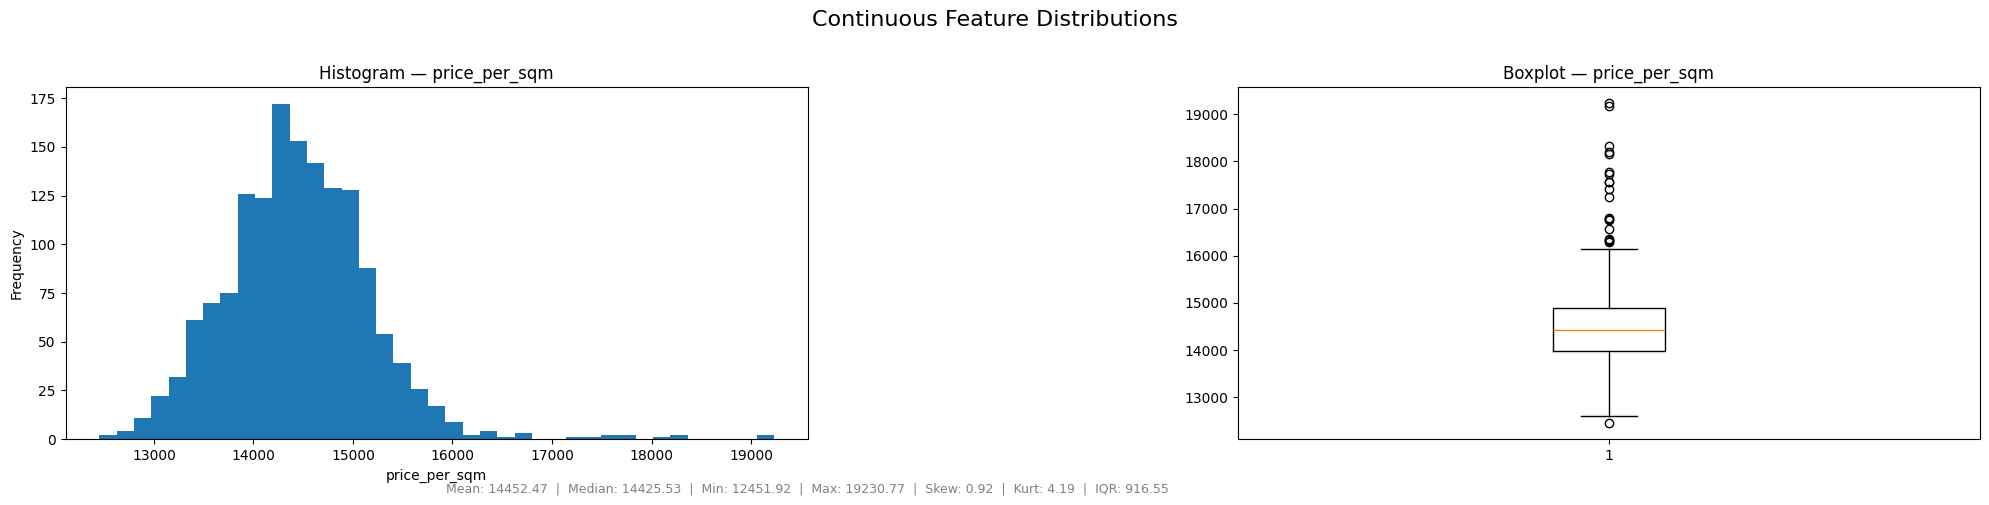

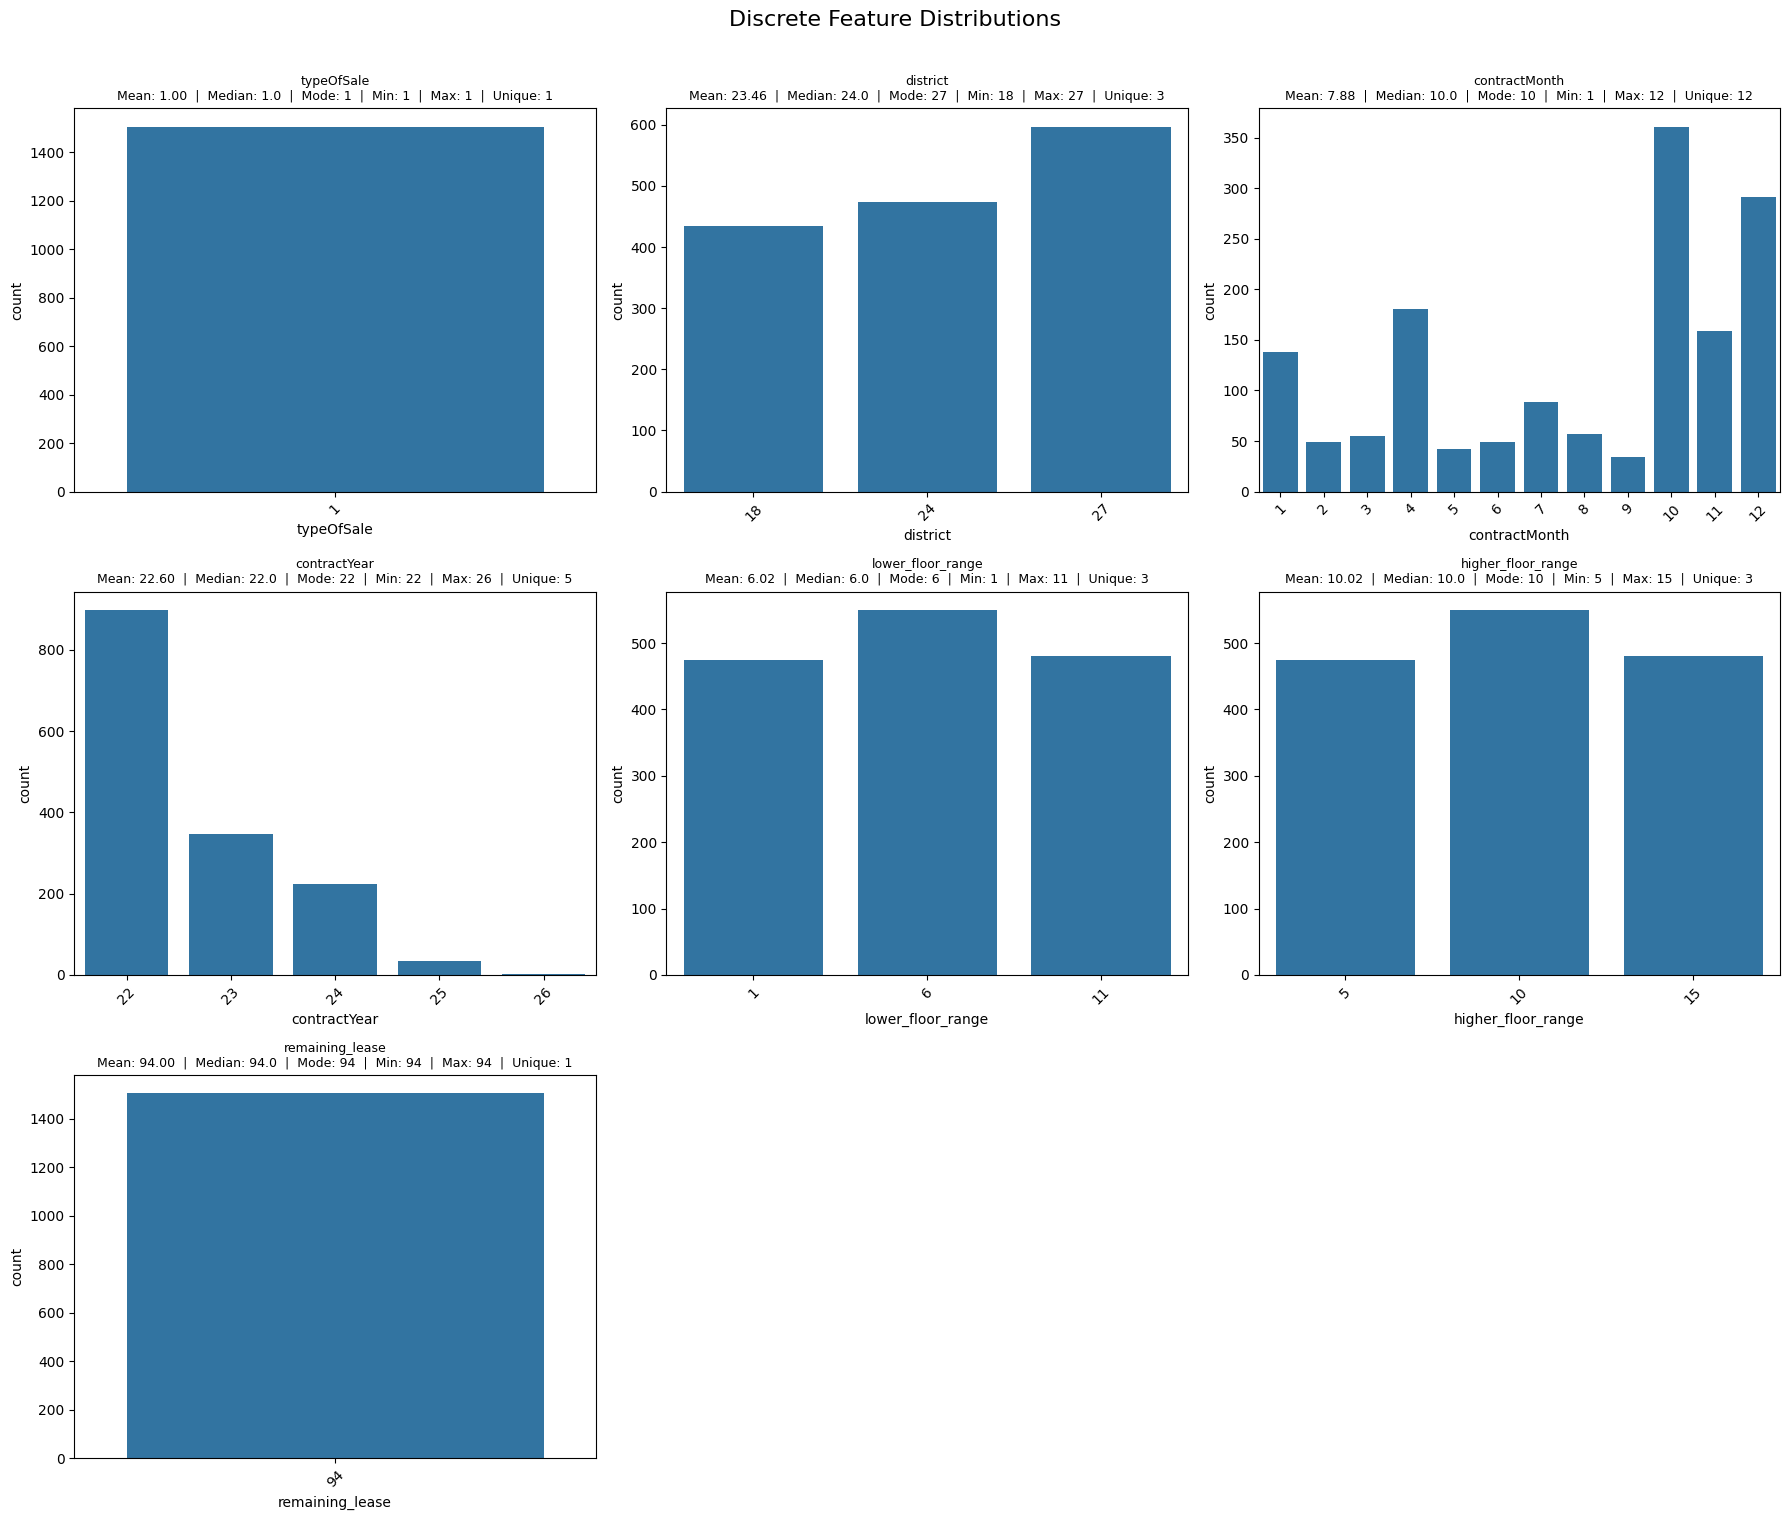

Value counts for typeOfSale:
typeOfSale
1    1505
Name: count, dtype: Int64
Total count: 1505


Value counts for district:
district
18    434
24    474
27    597
Name: count, dtype: Int64
Total count: 1505


Value counts for contractMonth:
contractMonth
1     138
2      49
3      55
4     181
5      42
6      49
7      89
8      57
9      34
10    361
11    159
12    291
Name: count, dtype: Int64
Total count: 1505


Value counts for contractYear:
contractYear
22    898
23    346
24    223
25     35
26      3
Name: count, dtype: Int64
Total count: 1505


Value counts for lower_floor_range:
lower_floor_range
1     475
6     550
11    480
Name: count, dtype: int64
Total count: 1505


Value counts for higher_floor_range:
higher_floor_range
5     475
10    550
15    480
Name: count, dtype: int64
Total count: 1505


Value counts for remaining_lease:
remaining_lease
94    1505
Name: count, dtype: int64
Total count: 1505




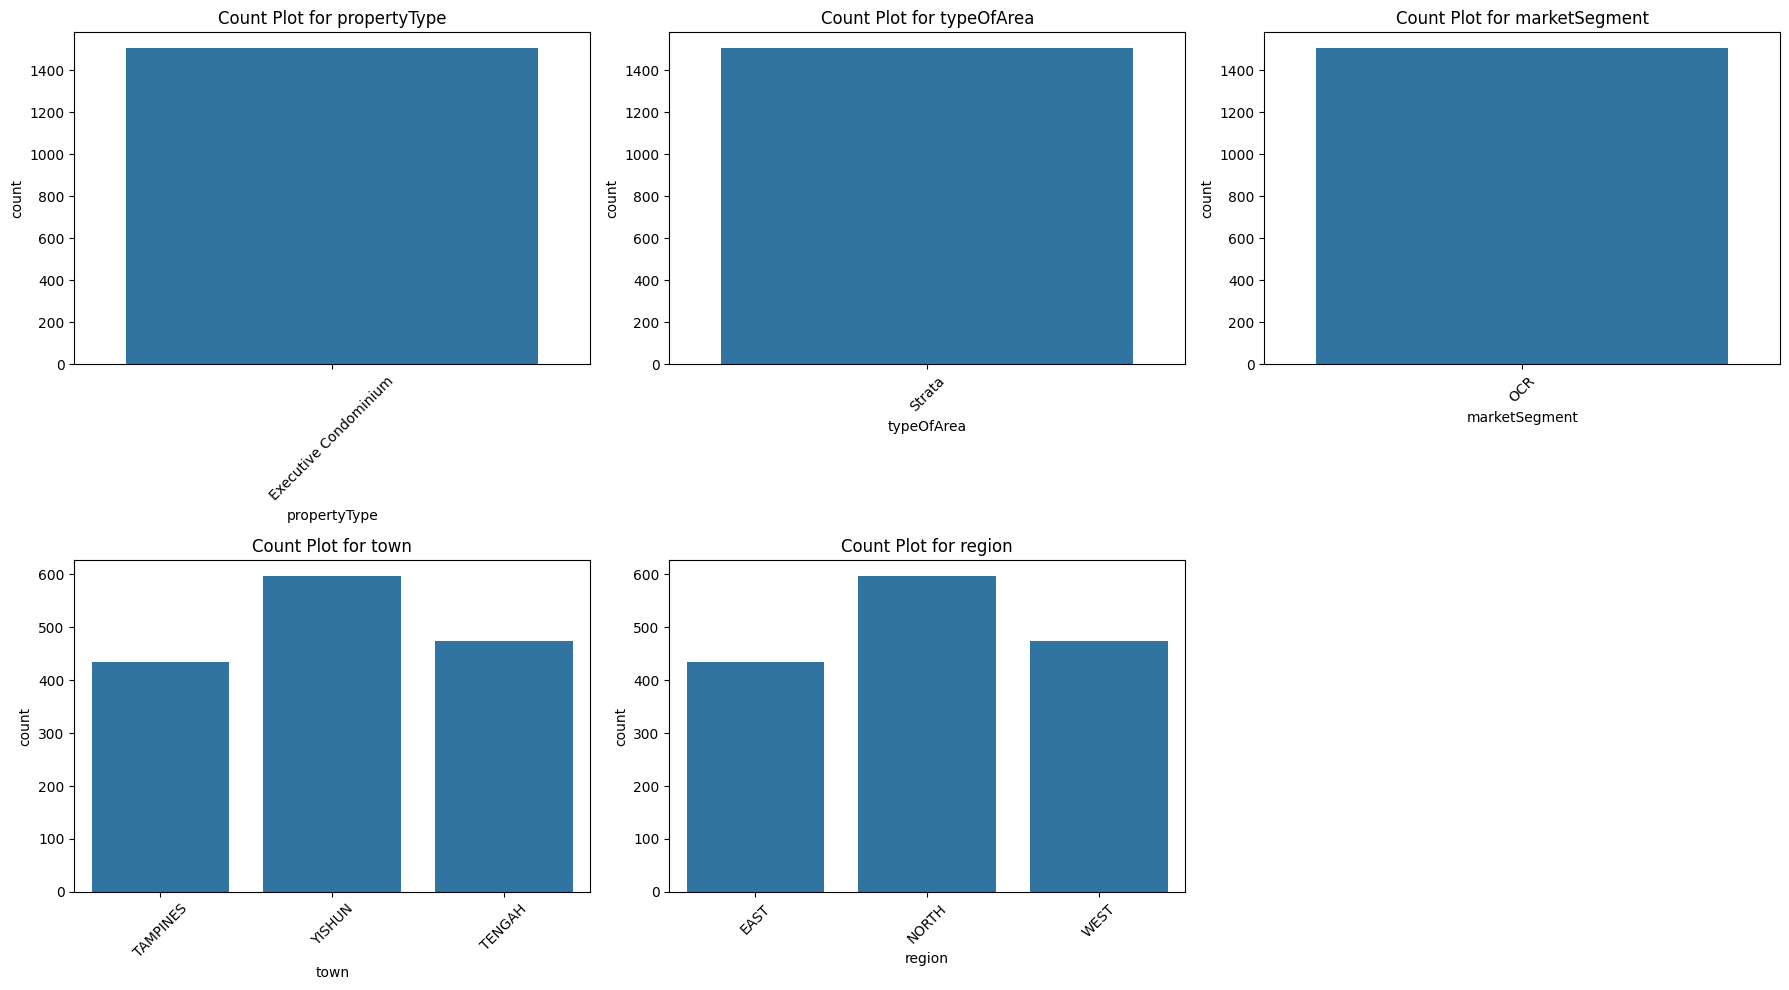

Value counts for propertyType:
propertyType
Executive Condominium    1505
Name: count, dtype: int64
Total count: 1505


Value counts for typeOfArea:
typeOfArea
Strata    1505
Name: count, dtype: int64
Total count: 1505


Value counts for marketSegment:
marketSegment
OCR    1505
Name: count, dtype: int64
Total count: 1505


Value counts for town:
town
YISHUN      597
TENGAH      474
TAMPINES    434
Name: count, dtype: int64
Total count: 1505


Value counts for region:
region
NORTH    597
WEST     474
EAST     434
Name: count, dtype: int64
Total count: 1505




In [50]:
plot_continuous_feature_distributions(df_lease_94, continous_columns)
plot_discrete_feature_distributions(df_lease_94, discrete_columns)
plot_categorical_feature_countplots(df_lease_94, categorical_columns)

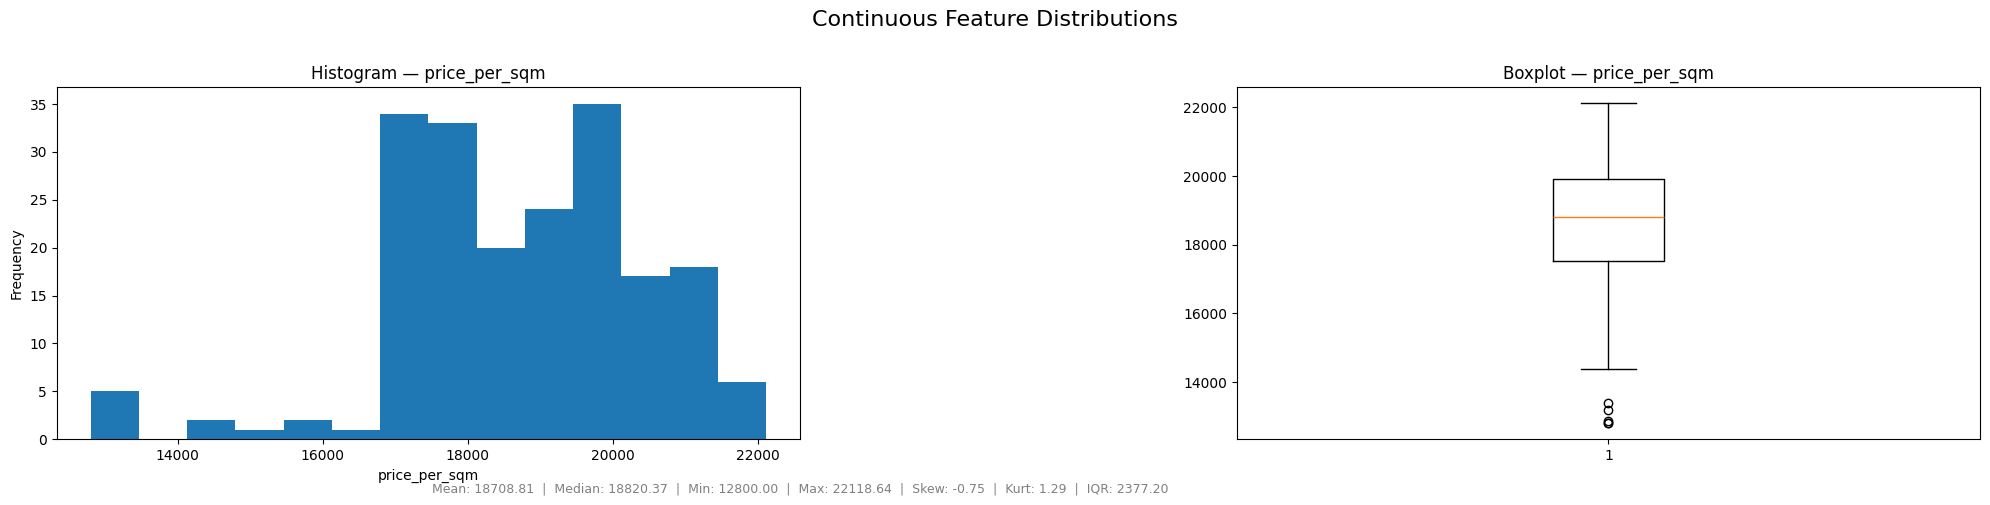

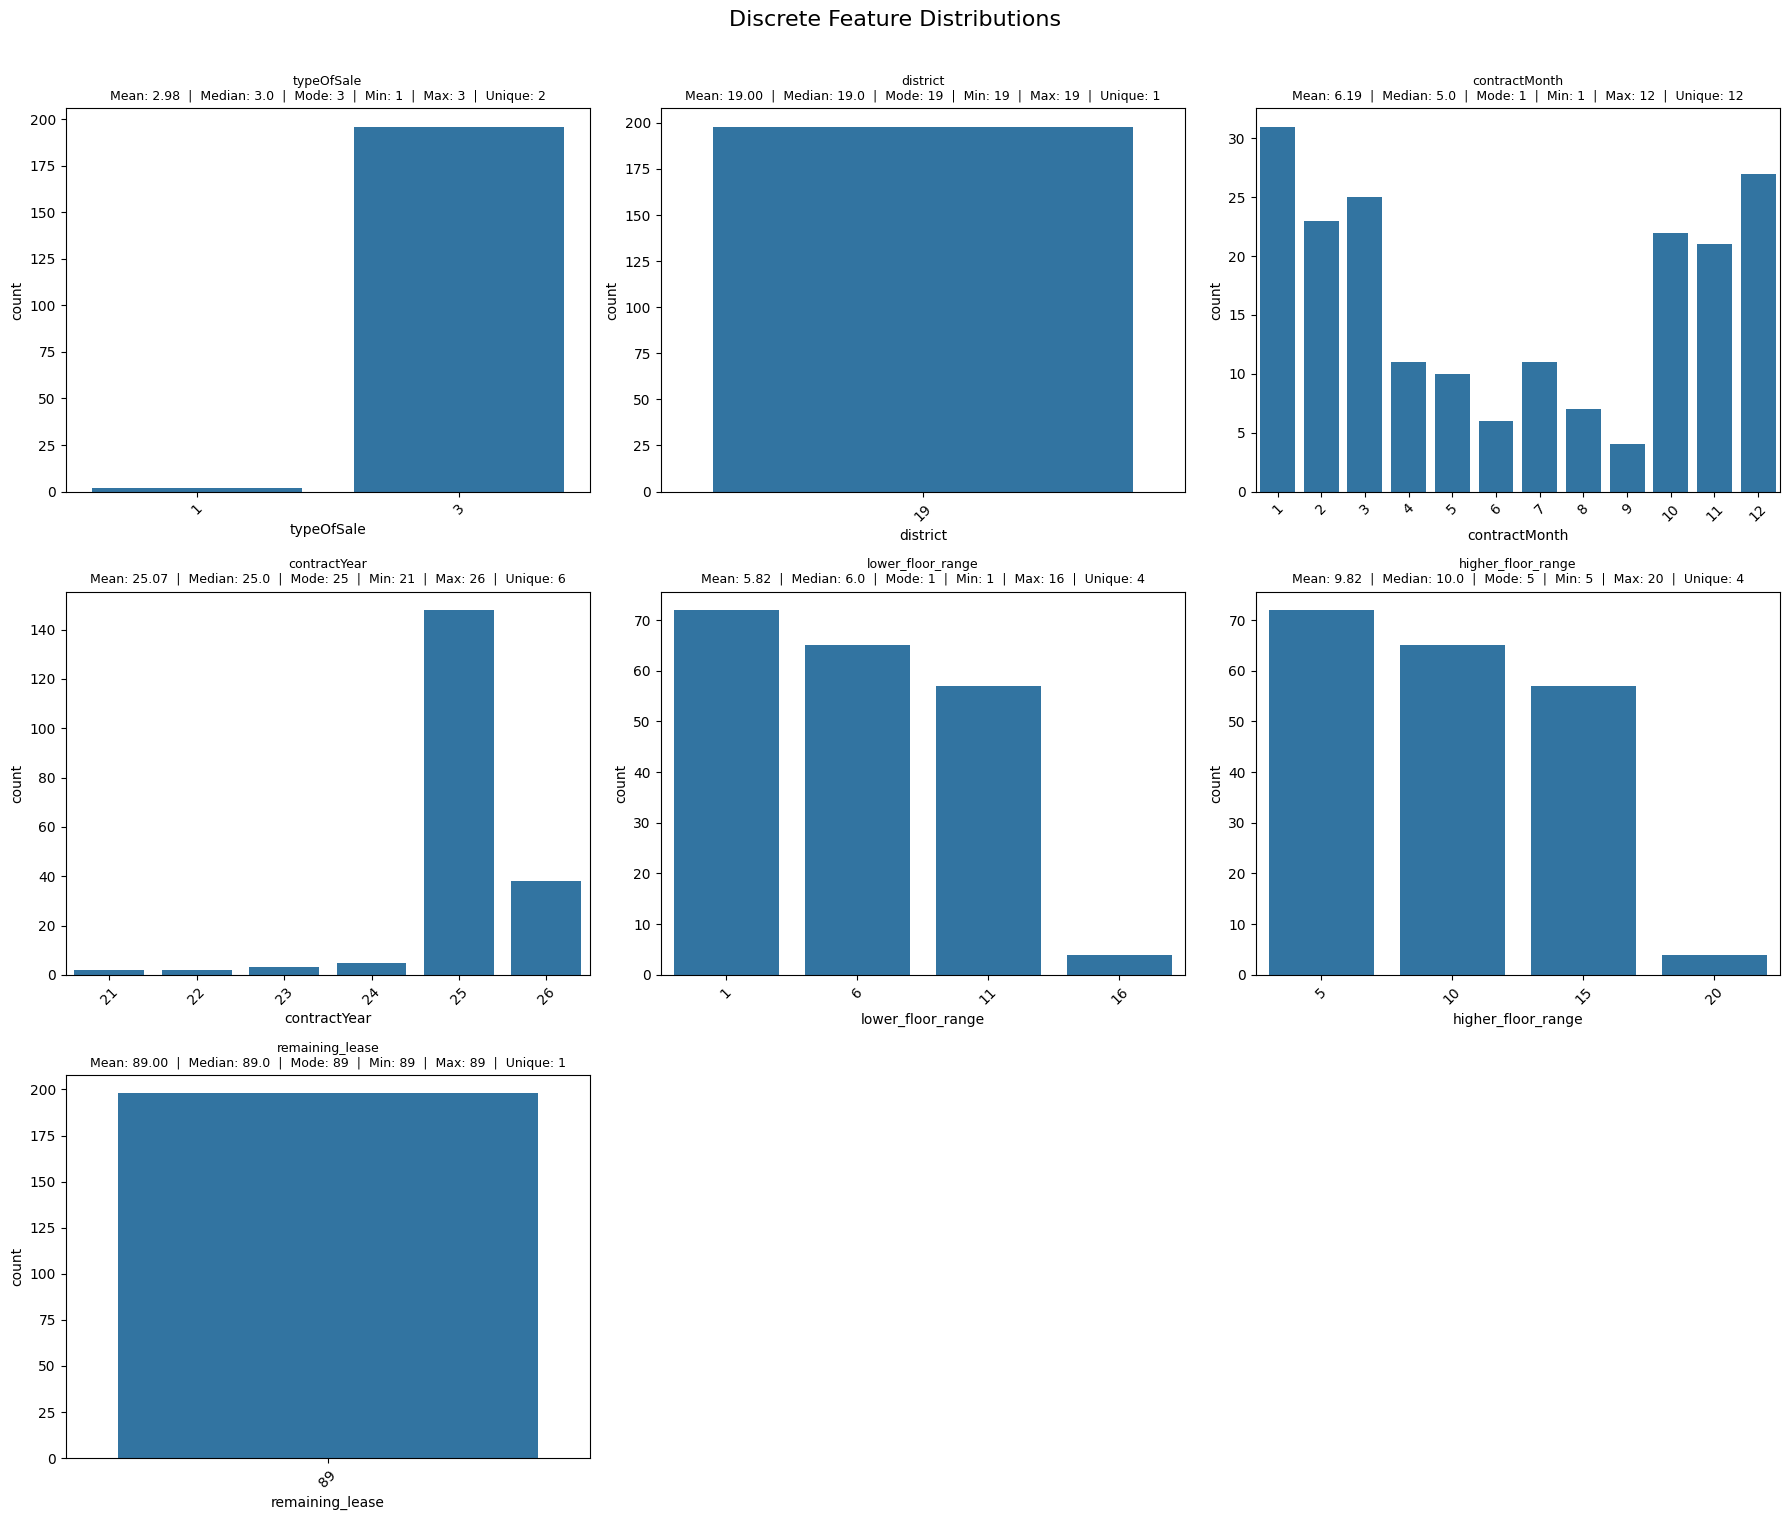

Value counts for typeOfSale:
typeOfSale
1      2
3    196
Name: count, dtype: Int64
Total count: 198


Value counts for district:
district
19    198
Name: count, dtype: Int64
Total count: 198


Value counts for contractMonth:
contractMonth
1     31
2     23
3     25
4     11
5     10
6      6
7     11
8      7
9      4
10    22
11    21
12    27
Name: count, dtype: Int64
Total count: 198


Value counts for contractYear:
contractYear
21      2
22      2
23      3
24      5
25    148
26     38
Name: count, dtype: Int64
Total count: 198


Value counts for lower_floor_range:
lower_floor_range
1     72
6     65
11    57
16     4
Name: count, dtype: int64
Total count: 198


Value counts for higher_floor_range:
higher_floor_range
5     72
10    65
15    57
20     4
Name: count, dtype: int64
Total count: 198


Value counts for remaining_lease:
remaining_lease
89    198
Name: count, dtype: int64
Total count: 198




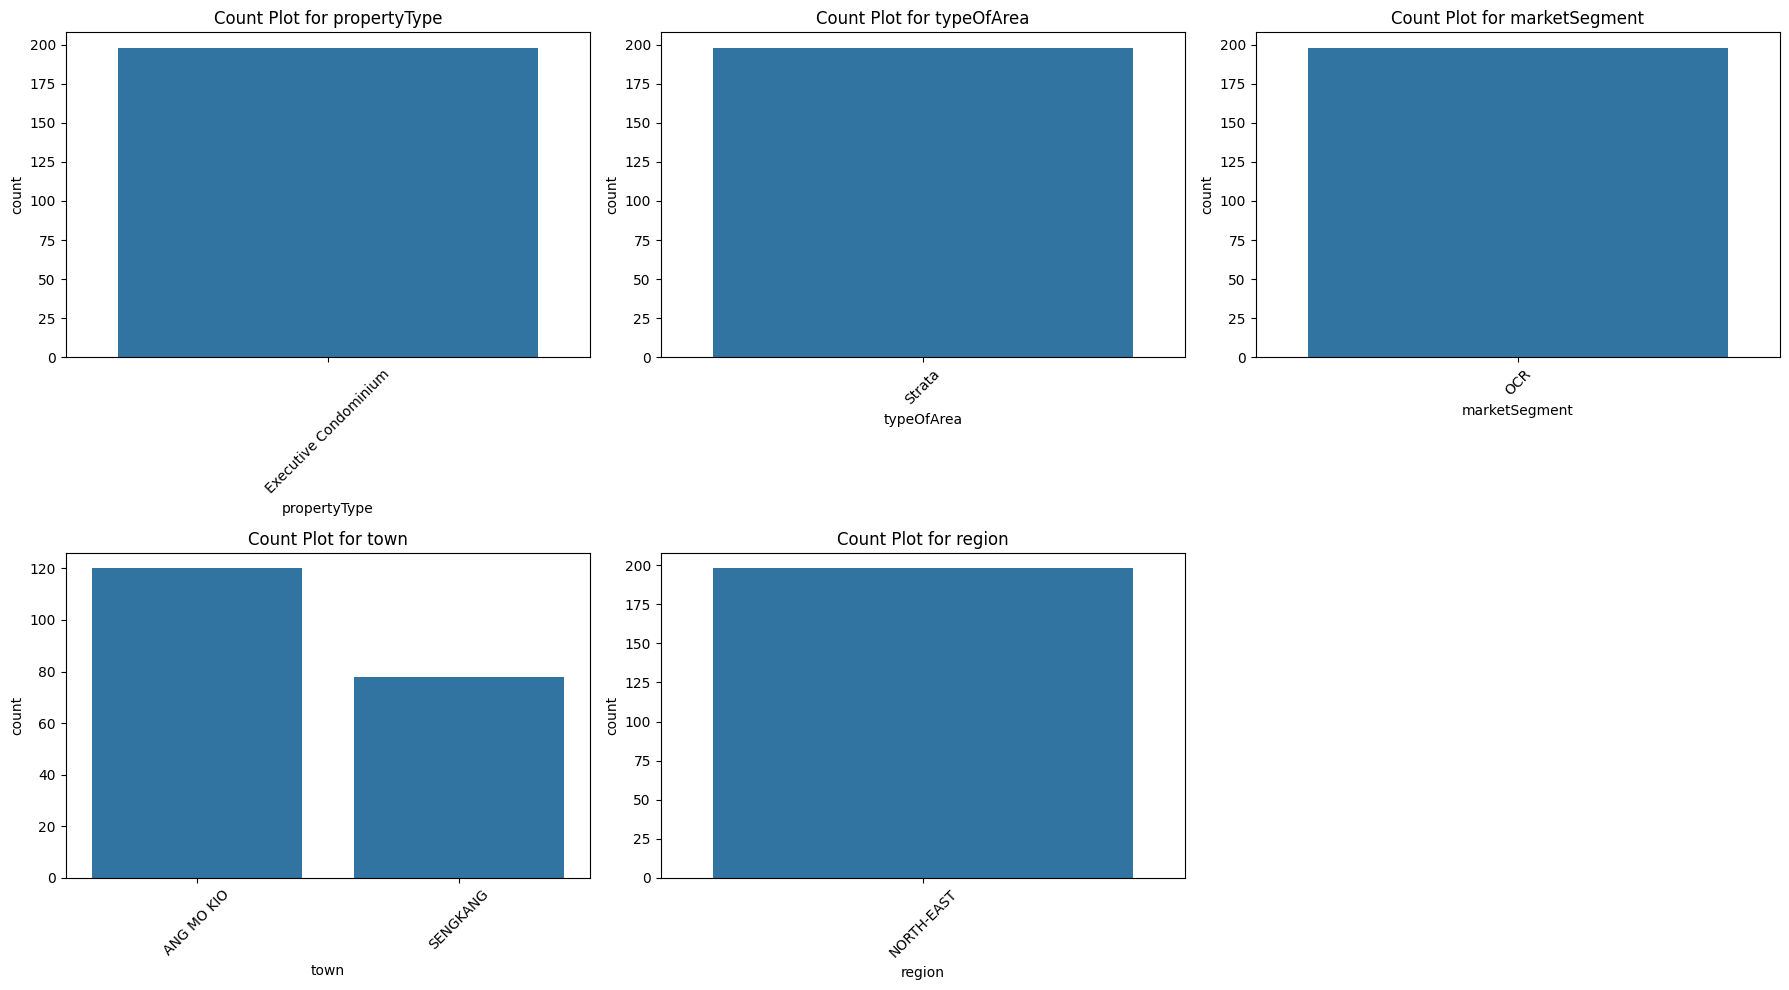

Value counts for propertyType:
propertyType
Executive Condominium    198
Name: count, dtype: int64
Total count: 198


Value counts for typeOfArea:
typeOfArea
Strata    198
Name: count, dtype: int64
Total count: 198


Value counts for marketSegment:
marketSegment
OCR    198
Name: count, dtype: int64
Total count: 198


Value counts for town:
town
ANG MO KIO    120
SENGKANG       78
Name: count, dtype: int64
Total count: 198


Value counts for region:
region
NORTH-EAST    198
Name: count, dtype: int64
Total count: 198




In [51]:
plot_continuous_feature_distributions(df_lease_89, continous_columns)
plot_discrete_feature_distributions(df_lease_89, discrete_columns)
plot_categorical_feature_countplots(df_lease_89, categorical_columns)

### 3. Bivariate Analysis 

In [71]:
def plot_bivariate(df_, label):
    num_cols = [c for c in df_.columns
                if df_[c].dtype in ('Float64', 'float64', 'Int64', 'int64')]
    plot_df = df_[num_cols].astype(float)

    # Pairplot
    g = sns.pairplot(plot_df, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
    g.fig.suptitle(f'Pairplot — {label}', y=1.02, fontsize=14)
    plt.show()

    # Pearson heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(plot_df.corr(method='pearson'), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
    ax.set_title(f'Pearson Correlation Heatmap — {label}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Spearman heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(plot_df.corr(method='spearman'), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
    ax.set_title(f'Spearman Correlation Heatmap — {label}', fontsize=14)
    plt.tight_layout()
    plt.show()


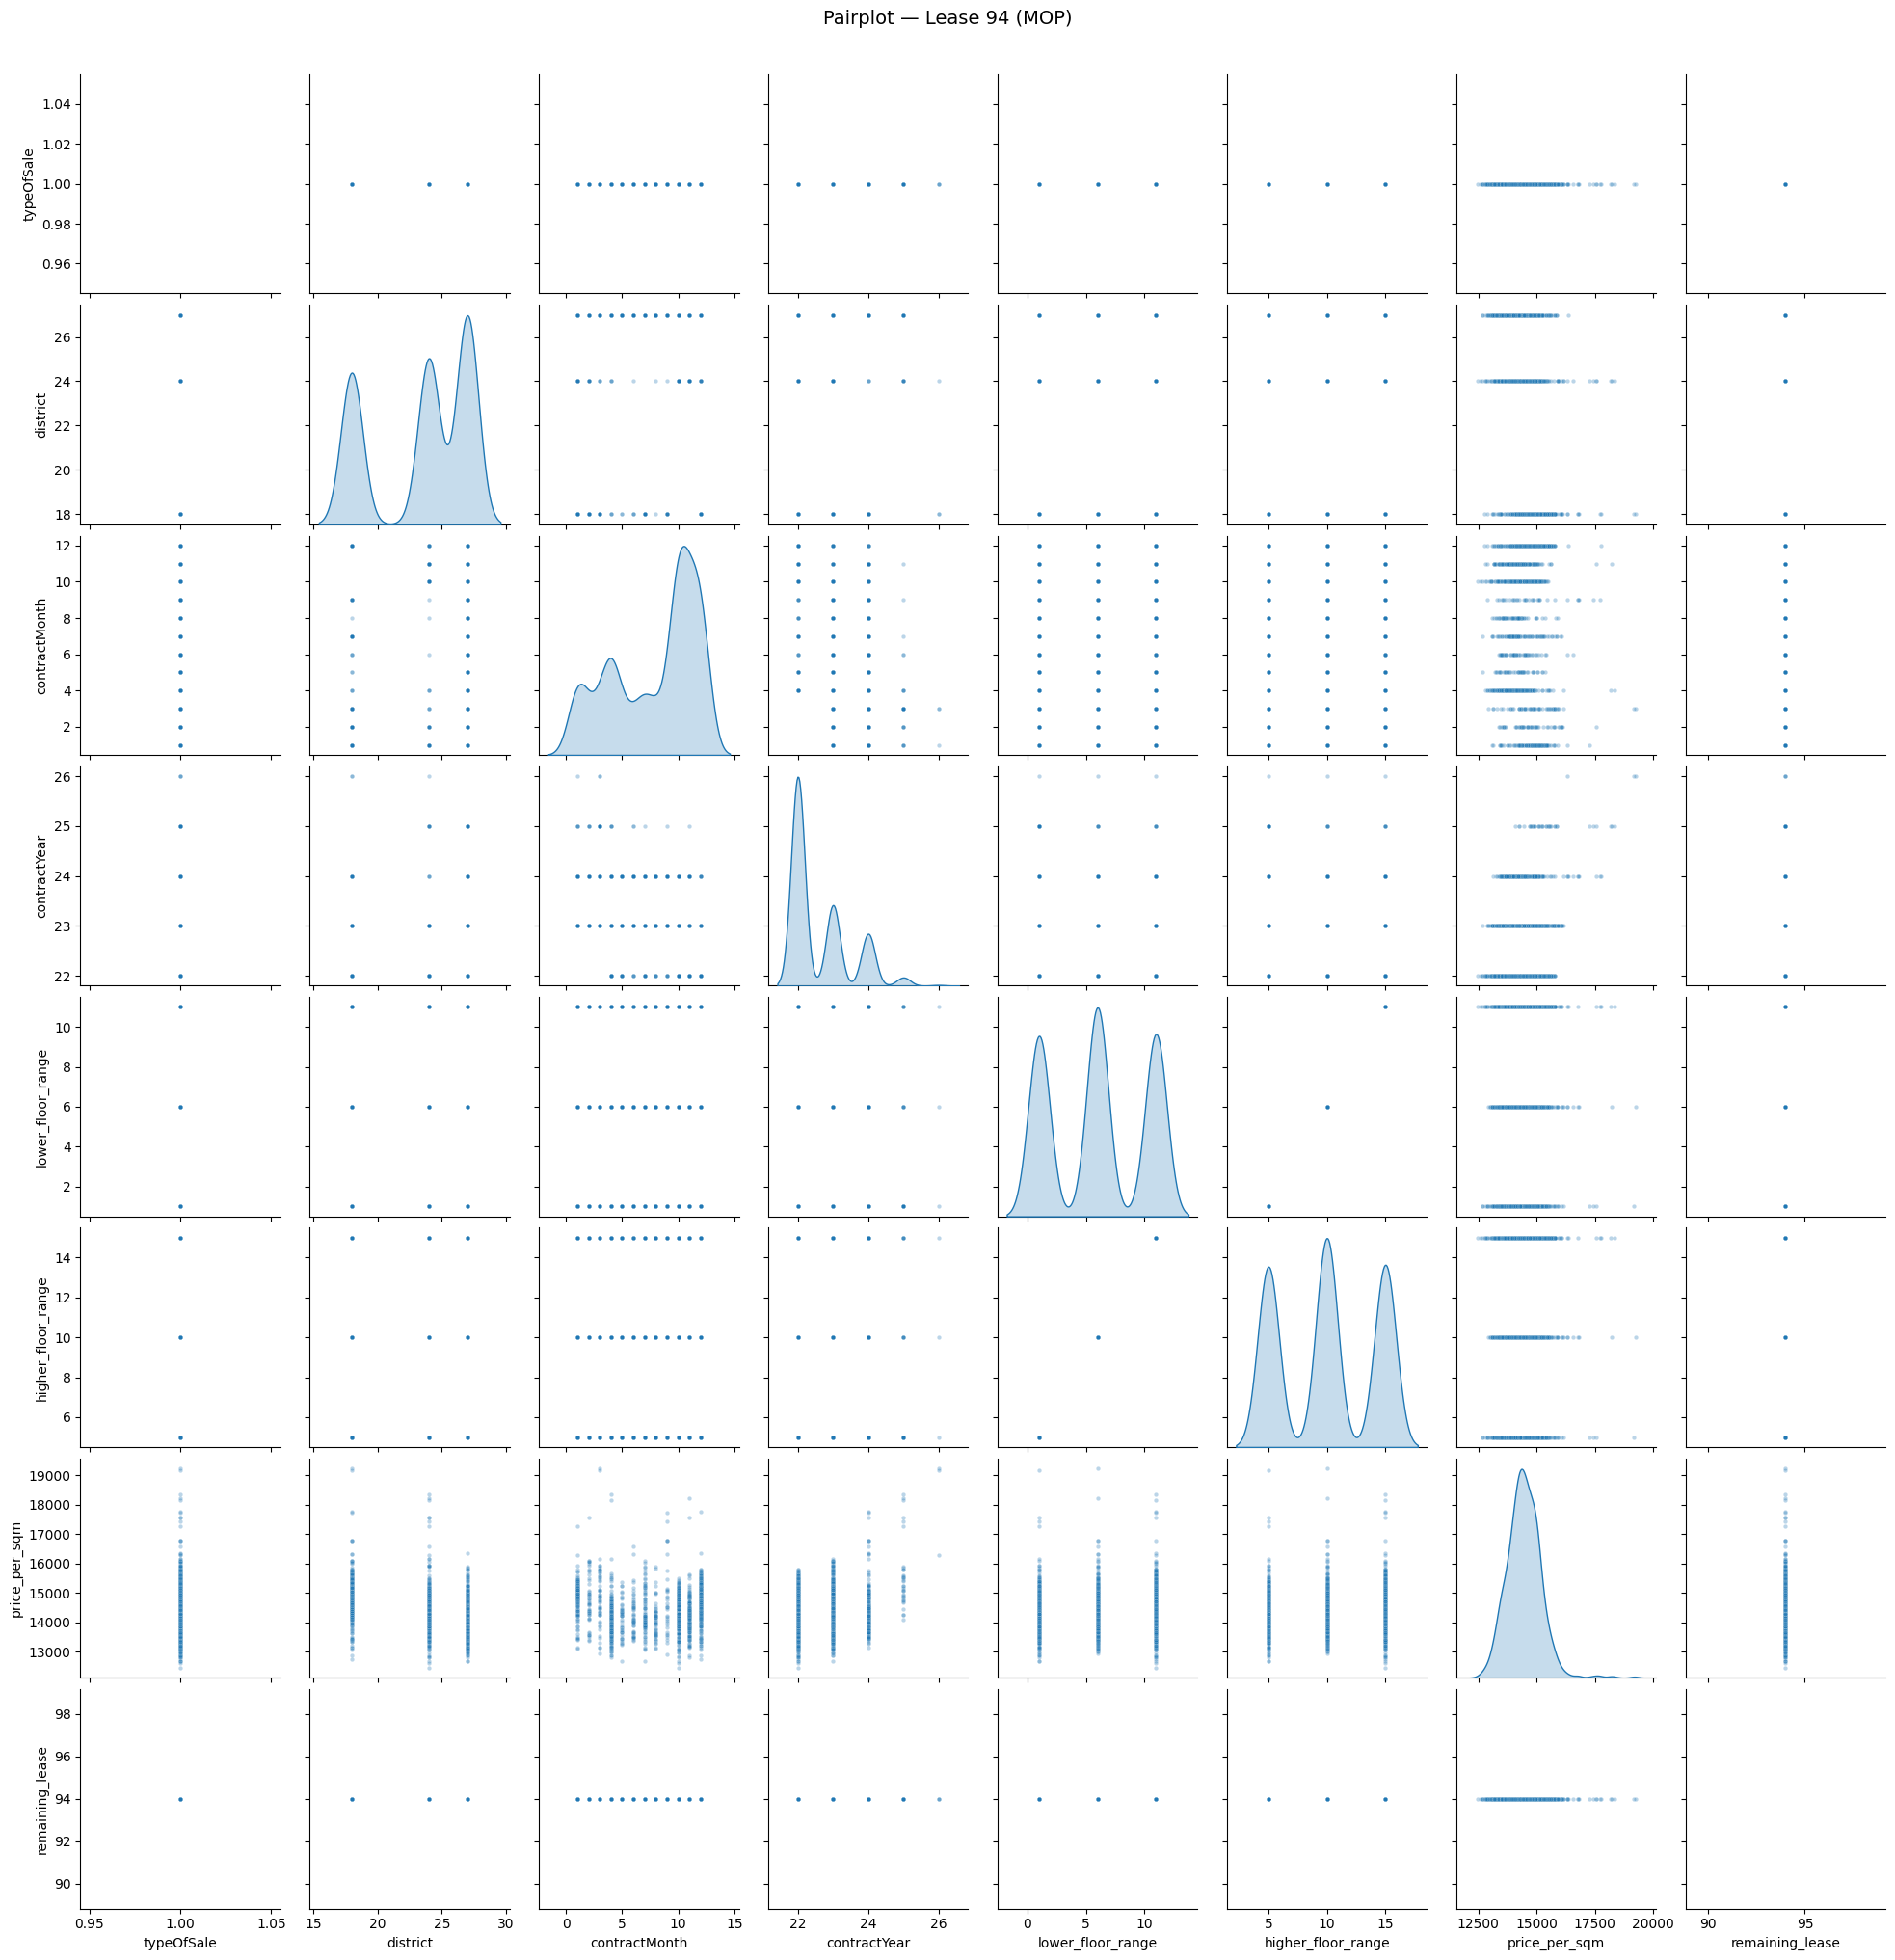

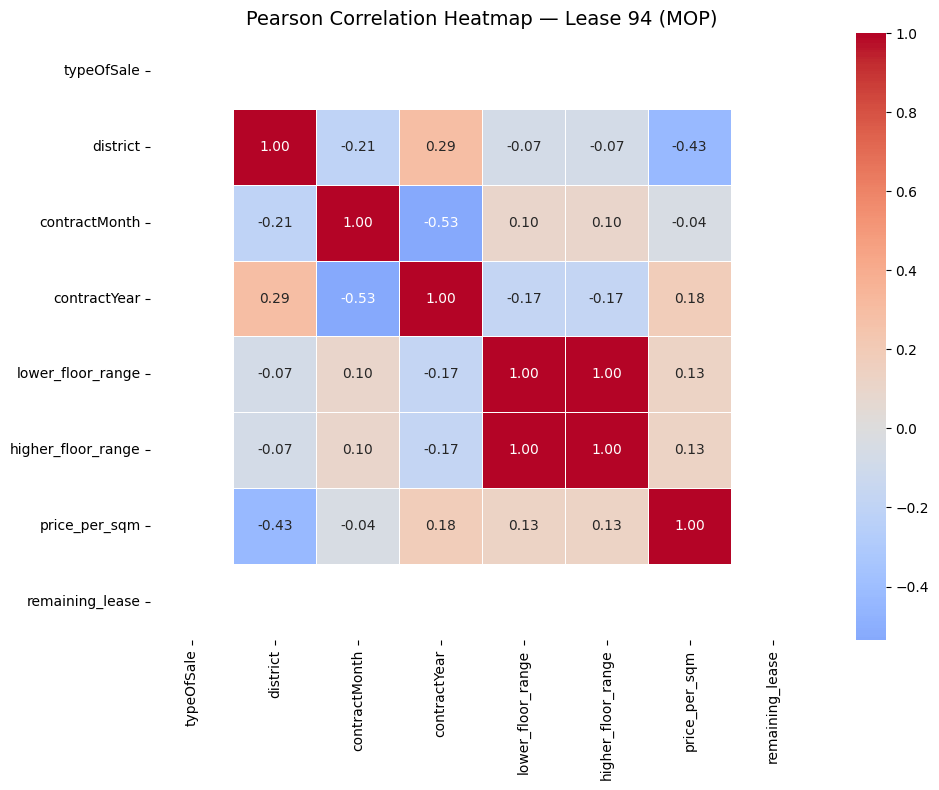

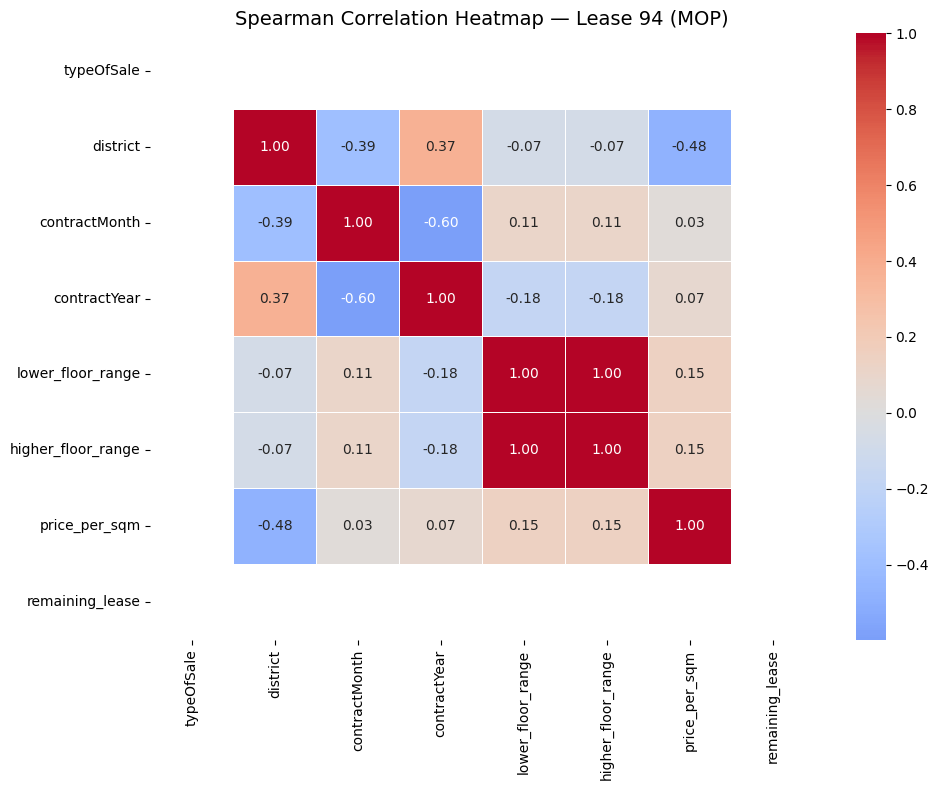

In [72]:
plot_bivariate(df_lease_94, 'Lease 94 (MOP)')


### Observation
- lower_floor_range and  higher_floor_range (0.13): weak positive effect
- contractMonth` (-0.04): no meaningful relationship
- district has the highest correlation with price_per_sqm (-0.43)
- lower_floor_range and higher_floor_range have perfect correlation (1.00) - multicol



TODO 
- remove lower_floor_range
- propertyType one hot encode
- typeOfArea one hot encode
- marketSegment one hot encode
- town one hot
- region one hot

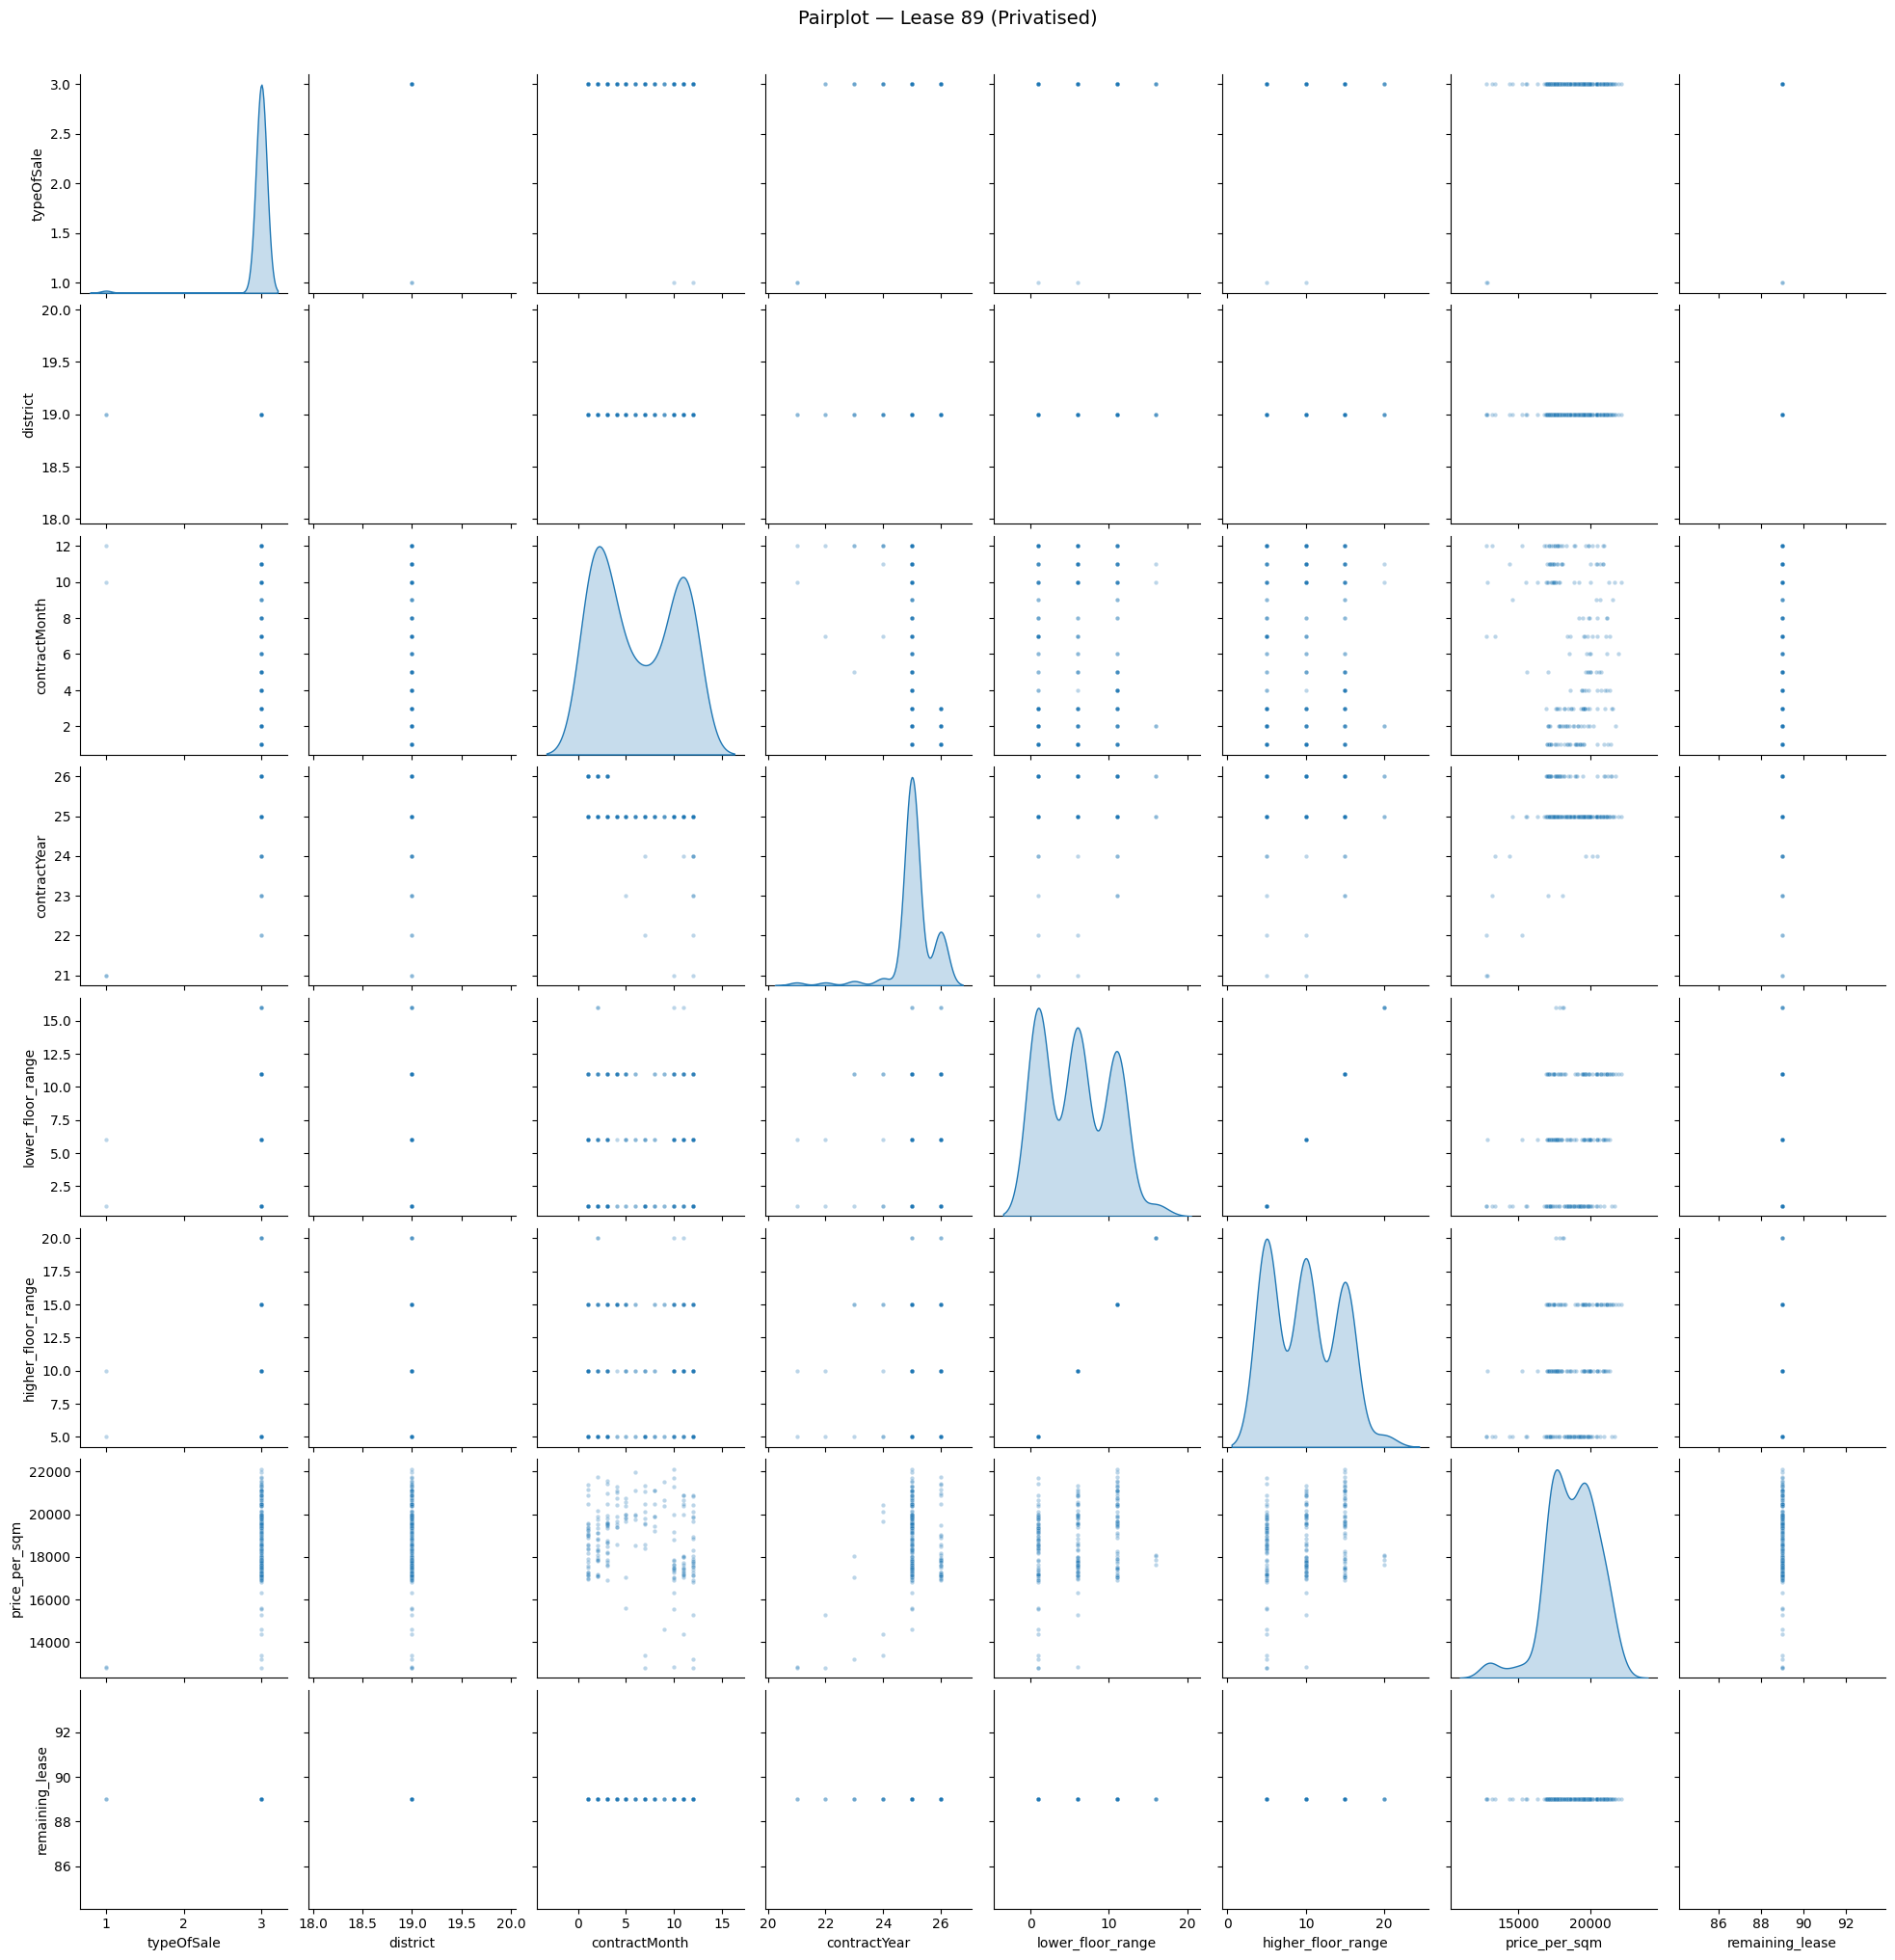

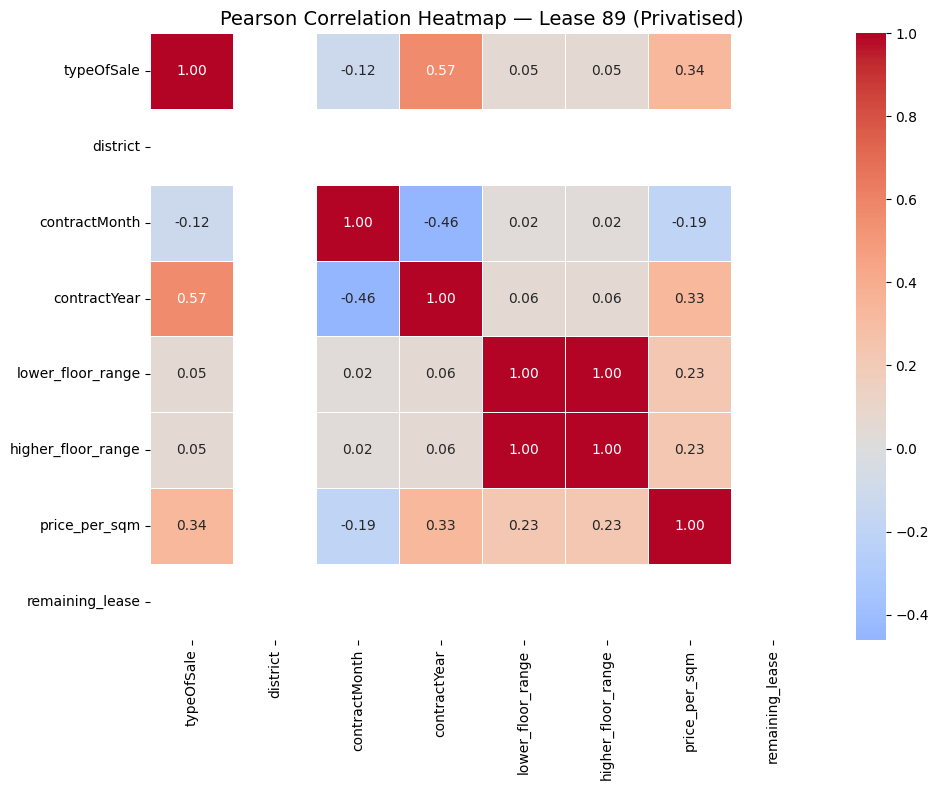

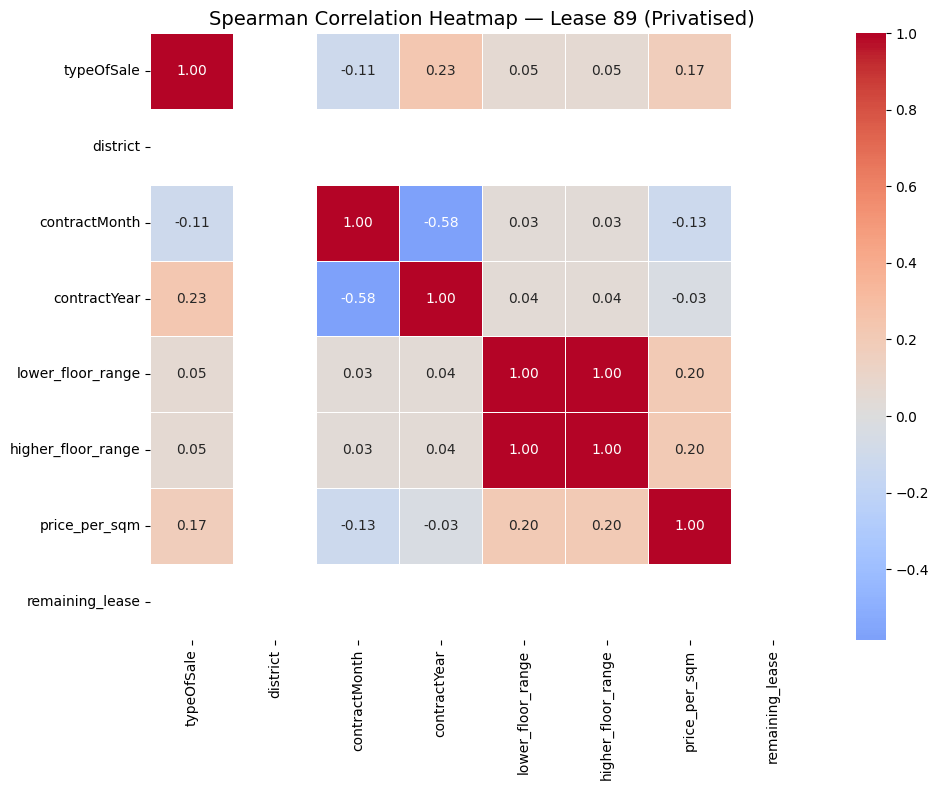

In [73]:
plot_bivariate(df_lease_89, 'Lease 89 (Privatised)')


### Observation
- typeofsale - weak positive corr
- contractMonth - very weak negative corr
- contractYear - weak positive corr
- lower floor and higher floor - weak positive corr
- lower_floor_range and higher_floor_range have perfect correlation (1.00) - multicol



TODO 
- remove lower_floor_range
- propertyType one hot encode
- typeOfArea one hot encode
- marketSegment one hot encode
- town one hot
- region one hot

# 4. Feature selection 

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def run_model_pipeline(df_processed, label):
    target_col = [c for c in df_processed.columns if 'price_per_sqm' in c][0]
    drop_cols  = [c for c in df_processed.columns if 'price_per_sqm' in c or 'remaining_lease' in c]

    X = df_processed.drop(columns=drop_cols).astype(float)
    y = df_processed[target_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # RFECV feature selection using RandomForest importance
    clf = RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe = RFECV(clf, cv=5, scoring='r2', verbose=1, n_jobs=-1)
    rfe.fit(X_train, y_train)

    X_train_sel = rfe.transform(X_train)
    X_test_sel  = rfe.transform(X_test)

    selected_features = X.columns[rfe.support_].tolist()
    print(f"\n[{label}] Optimal features ({rfe.n_features_}): {selected_features}")

    # Final model trained on RFECV-selected features
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_sel, y_train)
    y_pred = rf.predict(X_test_sel)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"[{label}] RMSE: {rmse:.2f}  |  R²: {r2:.4f}")

    return rf, rfe, selected_features


TODO 
- remove lower_floor_range
- propertyType one hot encode
- typeOfArea one hot encode
- marketSegment one hot encode
- town one hot
- region one hot

In [75]:
# Drop 'lower_floor_range' column from both datasets
df_lease_94 = df_lease_94.drop(columns=['lower_floor_range'])
df_lease_89 = df_lease_89.drop(columns=['lower_floor_range'])

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn import set_config

set_config(transform_output="pandas")

# Numeric features to scale (lower_floor_range already dropped)
scaling_list = [
    'typeOfSale', 'district', 'contractMonth', 'contractYear', 'higher_floor_range'
]

# Categorical features to one-hot encode
one_hot_list = ['propertyType', 'typeOfArea', 'marketSegment', 'town', 'region']

cat_columns_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

num_columns_pipeline = Pipeline(steps=[
    ('min_max_scaler', MinMaxScaler())
])

column_preprocessor_pipeline = ColumnTransformer(transformers=[
    ('num', num_columns_pipeline, scaling_list),
    ('cat', cat_columns_pipeline, one_hot_list)
], remainder='passthrough')  # price_per_sqm and remaining_lease pass through

main_preprocessing_pipeline = Pipeline(steps=[
    ('column_preprocessor', column_preprocessor_pipeline)
])

df_94_processed = main_preprocessing_pipeline.fit_transform(df_lease_94)
df_89_processed = main_preprocessing_pipeline.fit_transform(df_lease_89)

print('df_lease_94 processed shape:', df_94_processed.shape)
print('df_lease_89 processed shape:', df_89_processed.shape)
df_94_processed.head()


df_lease_94 processed shape: (1505, 16)
df_lease_89 processed shape: (198, 13)


,num__typeOfSale,num__district,num__contractMonth,num__contractYear,num__higher_floor_range,cat__propertyType_Executive Condominium,cat__typeOfArea_Strata,cat__marketSegment_OCR,cat__town_TAMPINES,cat__town_TENGAH,cat__town_YISHUN,cat__region_EAST,cat__region_NORTH,cat__region_WEST,remainder__price_per_sqm,remainder__remaining_lease
76161,0.0,0.0,0.090909,0.25,0.5,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,14941.860465,94
76162,0.0,0.0,0.090909,0.25,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,13401.960784,94
76163,0.0,0.0,0.090909,0.25,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,16075.342466,94
76164,0.0,0.0,0.090909,0.25,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,14397.590361,94
76165,0.0,0.0,0.090909,0.25,0.5,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,15620.689655,94


In [84]:
rf_94, rfe_94, features_94 = run_model_pipeline(df_94_processed, 'Lease 94 (MOP)')
rf_89, rfe_89, features_89 = run_model_pipeline(df_89_processed, 'Lease 89 (Privatised)')



[Lease 94 (MOP)] Selected 6 features: ['num__district', 'num__contractMonth', 'num__contractYear', 'num__higher_floor_range', 'cat__town_YISHUN', 'cat__region_NORTH']
[Lease 94 (MOP)] RMSE: 626.73  |  R²: 0.4519

[Lease 89 (Privatised)] Selected 4 features: ['num__contractMonth', 'num__contractYear', 'num__higher_floor_range', 'cat__town_ANG MO KIO']
[Lease 89 (Privatised)] RMSE: 784.18  |  R²: 0.8249


/Users/user/Documents/dsad_tech_assignment/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/user/Documents/dsad_tech_assignment/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
